In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Methodology 1

In [34]:
# Load the data 
sig_06 = pd.read_csv("../results/protein_sub_selection/significant_proteins_0.6.csv")
p_06 = pd.read_csv("../results/protein_sub_selection/p_values_0.6.csv")
sig_08 = pd.read_csv("../results/protein_sub_selection/significant_proteins_0.8.csv")
p_08 = pd.read_csv("../results/protein_sub_selection/p_values_0.8.csv")

#remove protein columns with no found significant in any iteration
sig_06 = sig_06.loc[:, (sig_06 != 0).any(axis=0)]
sig_08 = sig_08.loc[:, (sig_08 != 0).any(axis=0)]

# clean up iterations with less than 5 significant proteins
sig_06 = sig_06[sig_06.sum(axis=1) >= 5]
sig_08 = sig_08[sig_08.sum(axis=1) >= 5]


In [35]:
# vectors of significant proteins
# rows are iterations, columns are proteins
# match index to protein in sig df
M06 = sig_06.to_numpy().astype(int)
M08 = sig_08.to_numpy().astype(int)

print(M06.shape, M08.shape)

(1272, 2976) (1807, 1457)


## Hieraktiskt kluster med ward

In [46]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def jaccard_distance(mat):
    """Compute pairwise Jaccard distance matrix for binary matrix."""
    return squareform(pdist(mat, metric='jaccard'))

def ward_clustering(mat, name, sig_df, max_k=10):
    """
    Hierarchical Ward clustering on Jaccard distance matrix.
    
    mat    : binary matrix (iterations x proteins)
    name   : string label for plots (e.g. 'M06')
    sig_df : original sig dataframe to recover protein names
    max_k  : max number of clusters to evaluate
    """
    
    # --- 1. Jaccard distance matrix ---
    print(f"\n{'='*50}")
    print(f"{name}: {mat.shape[0]} iterations, {mat.shape[1]} proteins")
    dist_mat = jaccard_distance(mat)
    
    # --- 2. Ward linkage (requires condensed distance matrix) ---
    condensed = pdist(mat, metric='jaccard')
    Z = linkage(condensed, method='ward')
    
    # --- 3. Dendrogram ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    dendrogram(
        Z,
        ax=axes[0],
        truncate_mode='lastp',  # show only last p merges
        p=30,
        leaf_rotation=90,
        color_threshold=0.7 * max(Z[:, 2])
    )
    axes[0].set_title(f'{name} — Ward Dendrogram (truncated)')
    axes[0].set_xlabel('Iteration (sample count)')
    axes[0].set_ylabel('Distance')
    
    # --- 4. Elbow plot: within-cluster variance vs k ---
    inertias = []
    k_range = range(2, max_k + 1)
    
    for k in k_range:
        labels = fcluster(Z, k, criterion='maxclust')
        # Within-cluster sum of Jaccard distances to cluster centroid
        inertia = 0
        for c in range(1, k + 1):
            members = mat[labels == c]
            if len(members) > 1:
                centroid = members.mean(axis=0)
                dists = np.array([
                    np.sum(np.abs(row - centroid)) / 
                    (np.sum(row) + np.sum(centroid) - np.sum(np.minimum(row, centroid)) + 1e-10)
                    for row in members
                ])
                inertia += dists.sum()
        inertias.append(inertia)
    
    axes[1].plot(list(k_range), inertias, 'bo-')
    axes[1].set_xlabel('Number of clusters k')
    axes[1].set_ylabel('Within-cluster Jaccard inertia')
    axes[1].set_title(f'{name} — Elbow plot')
    axes[1].set_xticks(list(k_range))
    
    plt.tight_layout()
    plt.savefig(f'{name}_ward_overview.png', dpi=150)
    plt.show()
    
    return Z, dist_mat

def analyze_clusters(mat, Z, k, name, sig_df, top_n=15):
    labels = fcluster(Z, k, criterion="maxclust")
    protein_names = sig_df.columns

    df = pd.DataFrame(mat, columns=protein_names)
    df["cluster"] = labels

    freq = df.groupby("cluster").mean()
    counts = pd.DataFrame({
        "cluster": labels,
        "n_selected": mat.sum(axis=1)
    })

    print(f"\n{name} — cluster sizes")
    print(counts["cluster"].value_counts().sort_index())

    print(f"\n{name} — selected proteins per cluster")
    print(counts.groupby("cluster")["n_selected"].describe())

    top_proteins = freq.var(axis=0).nlargest(top_n).index

    fig, ax = plt.subplots(figsize=(12, 4))
    im = ax.imshow(freq.loc[:, top_proteins], aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
    ax.set_xticks(range(len(top_proteins)))
    ax.set_xticklabels(top_proteins, rotation=90, fontsize=8)
    ax.set_yticks(range(len(freq.index)))
    ax.set_yticklabels([f"C{c}" for c in freq.index])
    ax.set_title(f"{name}: protein frequency per cluster")
    plt.colorbar(im, ax=ax, label="Frequency flagged")
    plt.tight_layout()
    plt.show()

    plot_df = freq.loc[:, top_proteins].T
    plot_df.plot(kind="bar", figsize=(14, 5), width=0.8)
    plt.ylim(0, 1)
    plt.ylabel("Frequency flagged")
    plt.title(f"{name}: top discriminating proteins across clusters")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()

    return freq, labels, counts


M06: 1272 iterations, 2976 proteins


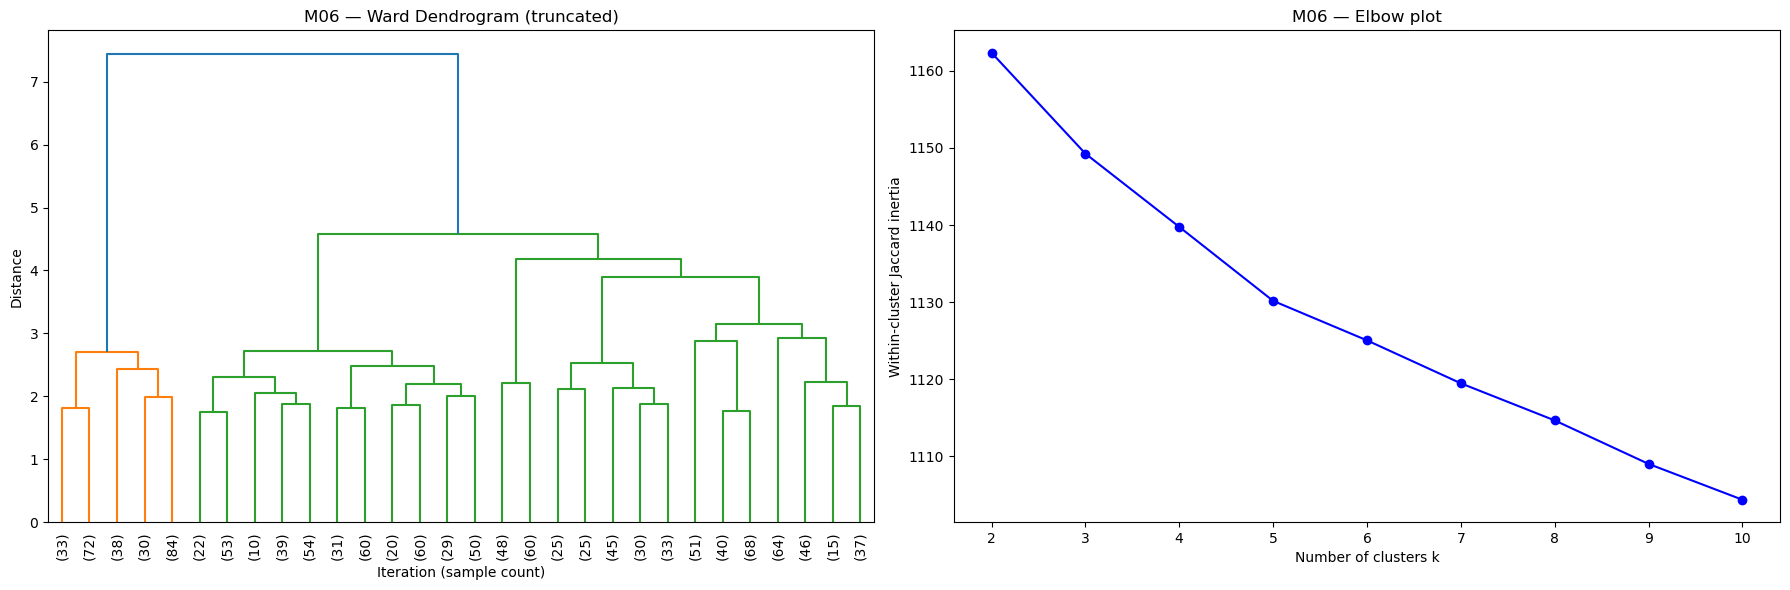


M08: 1807 iterations, 1457 proteins


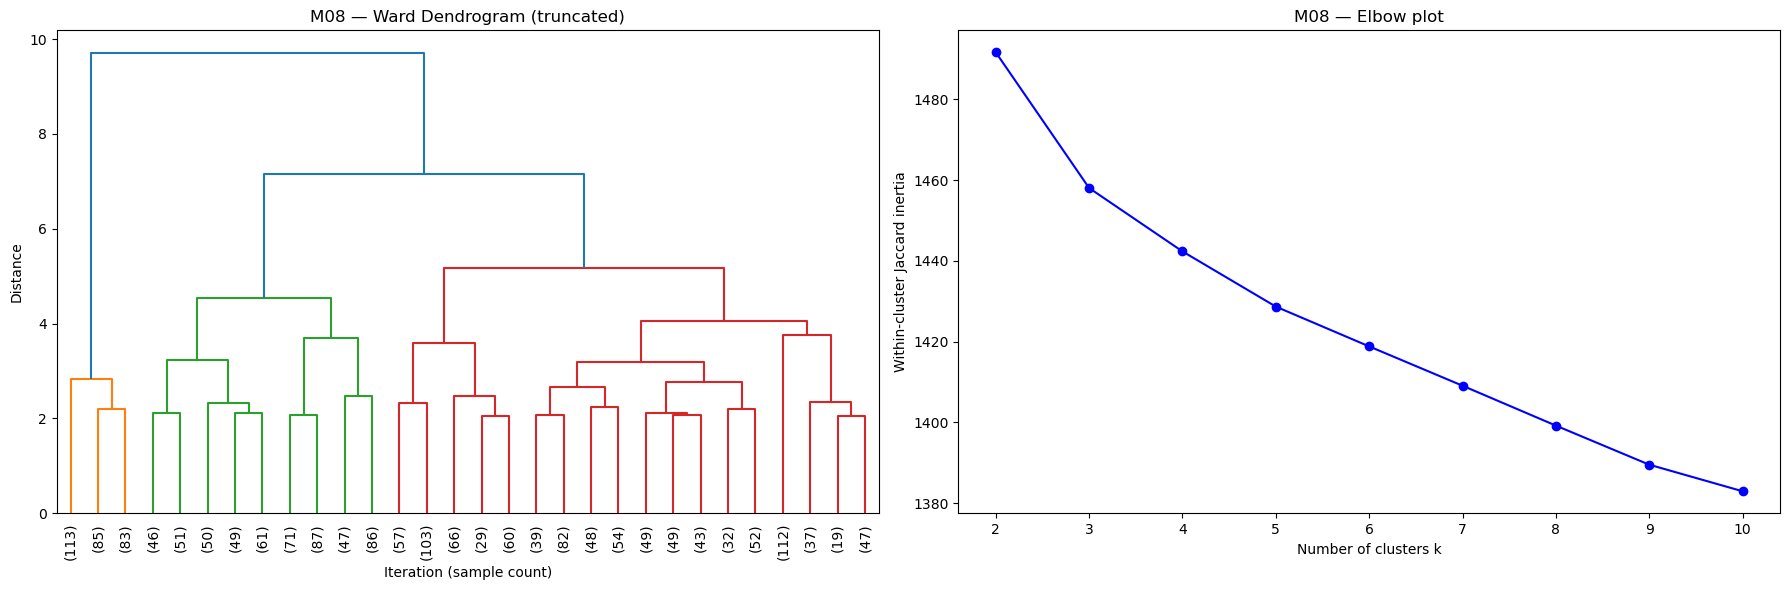


M06 — cluster sizes
cluster
1    257
2    428
3    587
Name: count, dtype: int64

M06 — selected proteins per cluster
         count       mean        std   min   25%   50%    75%    max
cluster                                                             
1        257.0  95.221790  58.816264  29.0  59.0  81.0  114.0  415.0
2        428.0  25.266355  55.966652   5.0   7.0  11.0   20.0  652.0
3        587.0  17.304940  11.611488   5.0   8.0  14.0   24.0   63.0


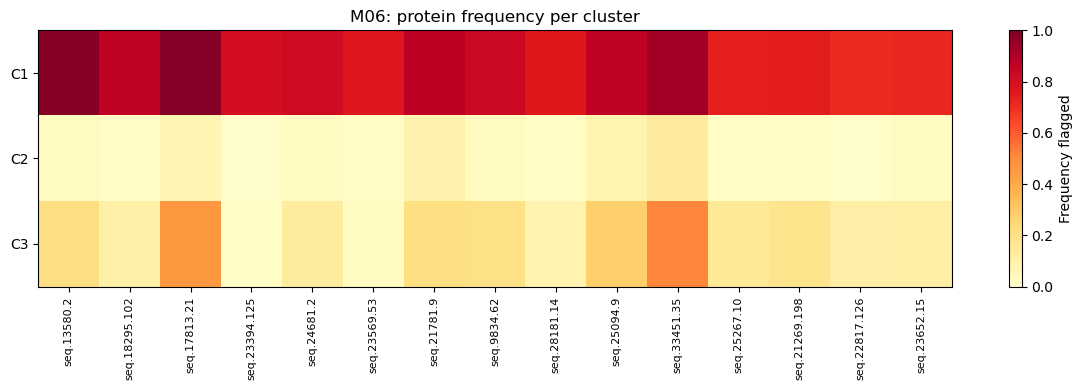

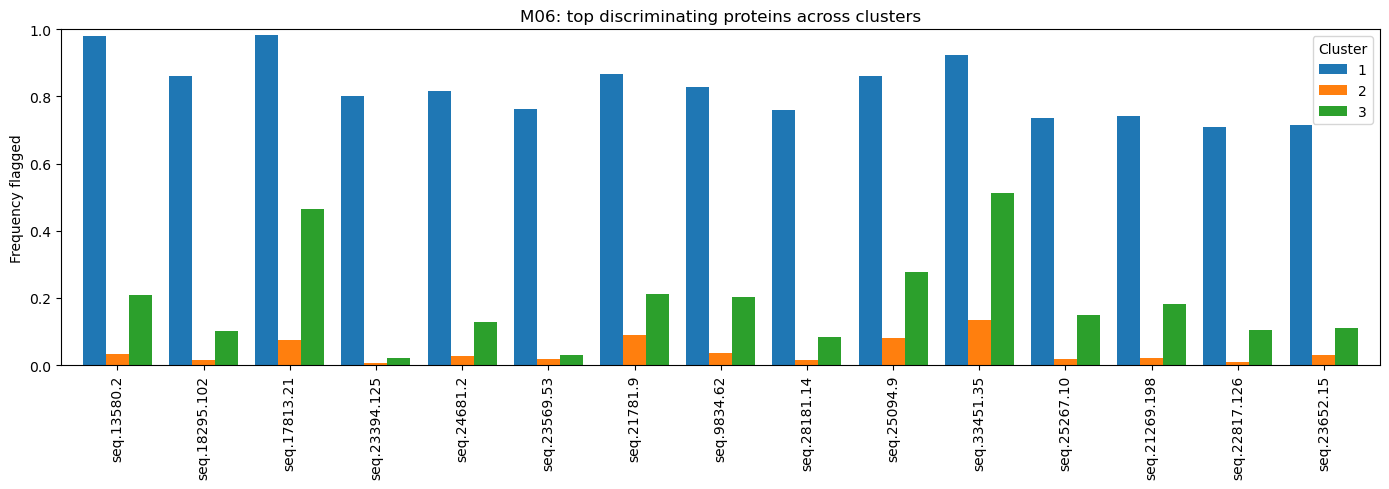


M08 — cluster sizes
cluster
1    281
2    548
3    978
Name: count, dtype: int64

M08 — selected proteins per cluster
         count       mean        std   min   25%   50%    75%    max
cluster                                                             
1        281.0  96.836299  47.394788  20.0  67.0  86.0  114.0  354.0
2        548.0  31.841241  17.043400   5.0  19.0  29.0   41.0  131.0
3        978.0  12.446830   6.868090   5.0   7.0  11.0   16.0   56.0


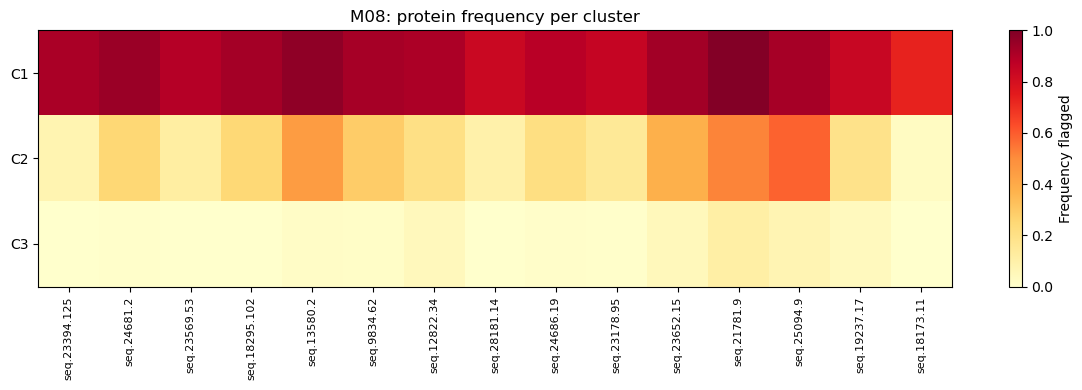

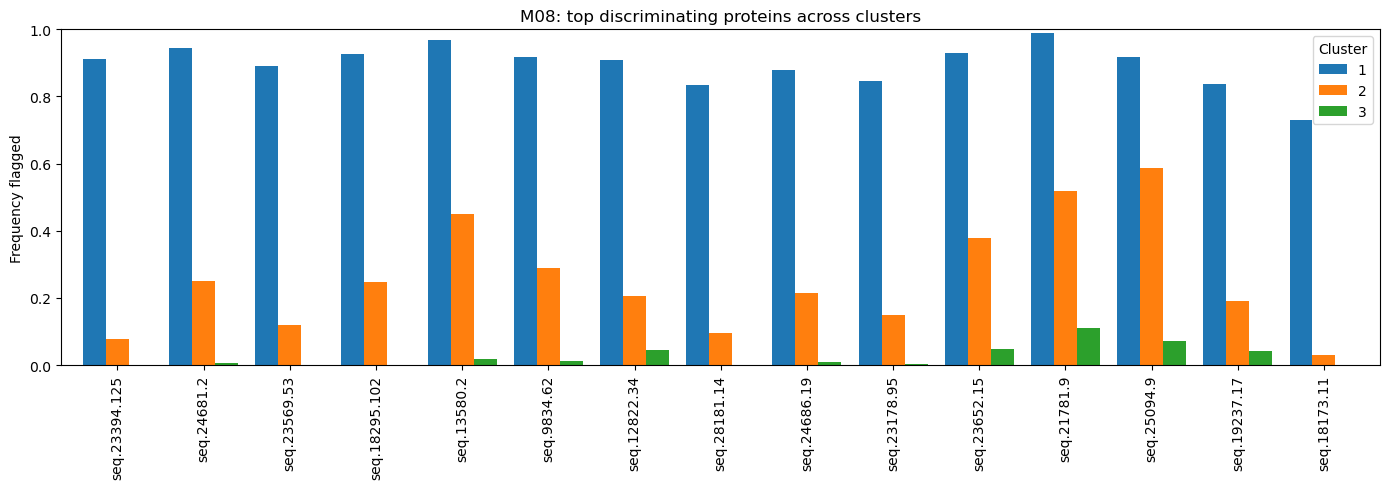


M06 — top proteiner per kluster:

  Kluster 1:
    seq.17813.21: 0.98
    seq.13580.2: 0.98
    seq.26103.20: 0.98
    seq.33451.35: 0.92
    seq.21781.9: 0.87
    seq.18295.102: 0.86
    seq.25094.9: 0.86
    seq.9834.62: 0.83
    seq.24681.2: 0.82
    seq.23394.125: 0.80

  Kluster 2:
    seq.26103.20: 0.43
    seq.23224.11: 0.34
    seq.7887.57: 0.33
    seq.18324.61: 0.26
    seq.34205.12: 0.25
    seq.12351.25: 0.21
    seq.33381.1: 0.21
    seq.18205.123: 0.21
    seq.22505.24: 0.21
    seq.7873.32: 0.20

  Kluster 3:
    seq.26103.20: 0.74
    seq.33451.35: 0.51
    seq.17813.21: 0.46
    seq.17792.158: 0.42
    seq.17725.37: 0.39
    seq.18205.123: 0.36
    seq.22528.1: 0.34
    seq.23224.11: 0.29
    seq.8983.7: 0.28
    seq.25094.9: 0.28

M08 — top proteiner per kluster:

  Kluster 1:
    seq.26103.20: 1.00
    seq.17813.21: 0.99
    seq.21781.9: 0.99
    seq.33451.35: 0.99
    seq.13580.2: 0.97
    seq.17792.158: 0.96
    seq.24681.2: 0.94
    seq.23652.15: 0.93
    seq.788

In [45]:
Z06, dist06 = ward_clustering(M06, 'M06', sig_06)
Z08, dist08 = ward_clustering(M08, 'M08', sig_08)

# Välj k baserat på dendrogram/elbow, sedan:
k06 = 3  # justera efter vad ni ser i dendrogrammet
k08 = 3

freq06, labels06, counts06 = analyze_clusters(M06, Z06, k06, "M06", sig_06)
freq08, labels08, counts08 = analyze_clusters(M08, Z08, k08, "M08", sig_08)

# Kolla top-proteiner per kluster
print("\nM06 — top proteiner per kluster:")
for c in freq06.index:
    top = freq06.loc[c].nlargest(10)
    print(f"\n  Kluster {c}:")
    for prot, val in top.items():
        print(f"    {prot}: {val:.2f}")

print("\nM08 — top proteiner per kluster:")
for c in freq08.index:
    top = freq08.loc[c].nlargest(10)
    print(f"\n  Kluster {c}:")
    for prot, val in top.items():
        print(f"    {prot}: {val:.2f}")

# -log10 transformation av p-värdena

Verkar som att alla kluster använder samma proteiner men att de fångar signalstyrka, inte olika biologiska mekanismer.

Ny hypotes: en dominant signal + variation i styrka, inte flera endotyper



## UMAP

In [55]:
import umap
from sklearn.cluster import DBSCAN

def run_umap_clustering(
    mat,
    metric="jaccard",
    n_neighbors=10,
    min_dist=0.05,
    eps=0.3,
    min_samples=10,
    plot=True,
    title="UMAP clustering"
):
    """
    Kör UMAP + DBSCAN på en binär matris (iteration x protein)

    Returns:
        embedding: (n_samples, 2)
        labels: klusterlabel per rad (-1 = noise)
    """

    # --- UMAP ---
    reducer = umap.UMAP(
        metric=metric,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=42
    )

    embedding = reducer.fit_transform(mat)

    # --- DBSCAN ---
    clustering = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = clustering.fit_predict(embedding)

    # --- Plot ---
    if plot:
        plt.figure(figsize=(6, 5))

        unique_labels = np.unique(labels)
        for lab in unique_labels:
            mask = labels == lab
            if lab == -1:
                plt.scatter(
                    embedding[mask, 0],
                    embedding[mask, 1],
                    s=10,
                    label="noise",
                    alpha=0.5
                )
            else:
                plt.scatter(
                    embedding[mask, 0],
                    embedding[mask, 1],
                    s=10,
                    label=f"cluster {lab}"
                )

        plt.legend()
        plt.title(title)
        plt.xlabel("UMAP1")
        plt.ylabel("UMAP2")
        plt.tight_layout()
        plt.show()

    return embedding, labels

/opt/anaconda3/envs/exjobb/lib/python3.11/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/opt/anaconda3/envs/exjobb/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


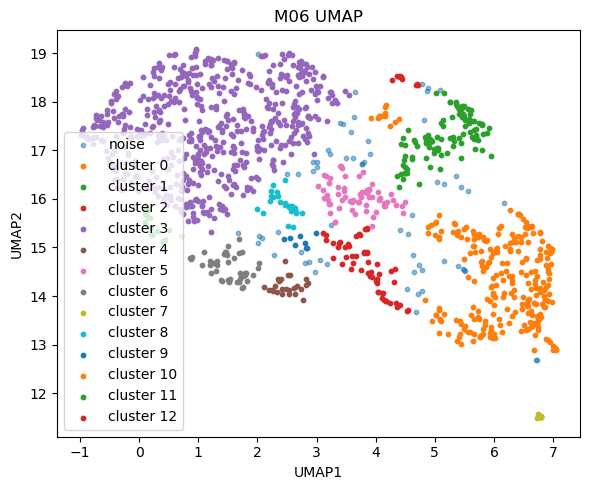

/opt/anaconda3/envs/exjobb/lib/python3.11/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/opt/anaconda3/envs/exjobb/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


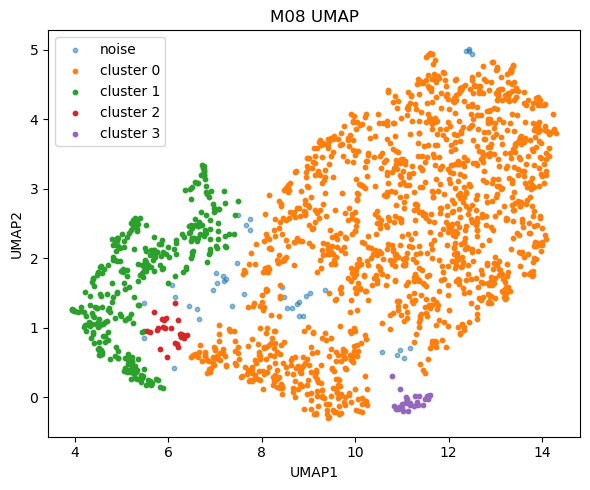

In [56]:
emb06, labels06 = run_umap_clustering(M06, title="M06 UMAP")
emb08, labels08 = run_umap_clustering(M08, title="M08 UMAP")

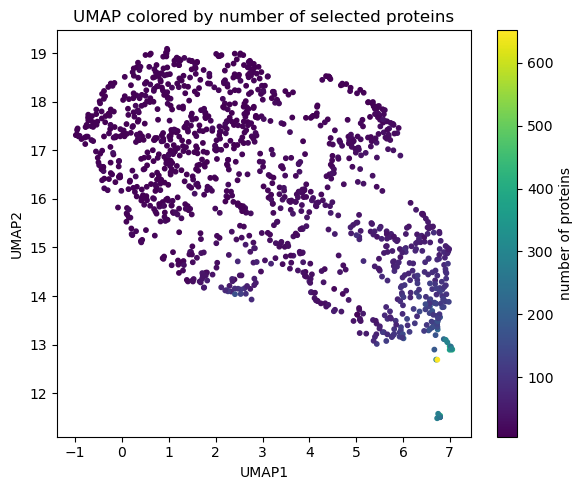

In [61]:
df_umap = pd.DataFrame(emb06, columns=["UMAP1", "UMAP2"])
df_umap["n_proteins"] = M06.sum(axis=1)
plt.figure(figsize=(6,5))

sc = plt.scatter(
    df_umap["UMAP1"],
    df_umap["UMAP2"],
    c=df_umap["n_proteins"],
    cmap="viridis",
    s=10
)

plt.colorbar(sc, label="number of proteins")
plt.title("UMAP colored by number of selected proteins")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.tight_layout()
plt.show()

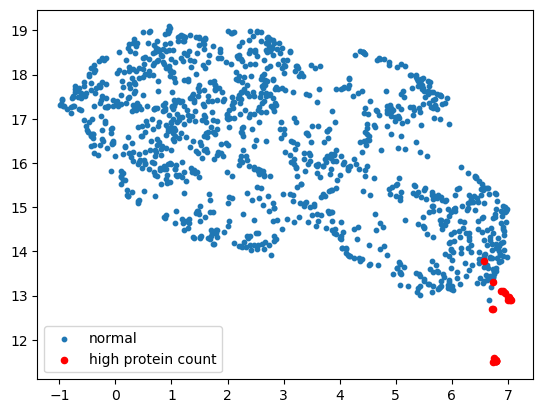

In [66]:
mask = df_umap["n_proteins"] > 200  # justera cutoff

plt.scatter(
    df_umap["UMAP1"][~mask],
    df_umap["UMAP2"][~mask],
    s=10,
    label="normal"
)

plt.scatter(
    df_umap["UMAP1"][mask],
    df_umap["UMAP2"][mask],
    color="red",
    s=20,
    label="high protein count"
)

plt.legend()
plt.show()

UMAP verkar inte driavs av antal proteiner utan av vilka proteiner som väljs

In [58]:
from sklearn.linear_model import LinearRegression

X = M06
y = emb06[:, 0]

model = LinearRegression().fit(X, y)
importance = model.coef_

In [65]:
# Print the proteins with the highest positive and negative coefficients
protein_names = sig_06.columns
coef_df = pd.DataFrame({
    "protein": protein_names,
    "coefficient": importance
}).sort_values(by="coefficient", ascending=False)
print(coef_df.head(5))
print(coef_df.tail(5))


            protein  coefficient
1204   seq.23555.11    20.171581
1671   seq.29392.76    18.674274
1344  seq.24943.117    17.049814
1549   seq.28386.42    15.279127
1911   seq.31618.22    14.902882
           protein  coefficient
1547  seq.28361.10   -15.556754
2727   seq.8074.32   -15.906160
2721   seq.8032.23   -16.004832
305   seq.12825.18   -16.782127
487    seq.14208.3   -18.396984


In [59]:
low = emb06[:,0] < np.percentile(emb06[:,0], 33)
high = emb06[:,0] > np.percentile(emb06[:,0], 66)

## Projection based clustering

Beräknar Jaccard-distansmatris för M06...
Kör Ward...
Ward silhouette: 0.034
Kör UMAP...


/opt/anaconda3/envs/exjobb/lib/python3.11/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/opt/anaconda3/envs/exjobb/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Kör HDBSCAN...
HDBSCAN hittade 12 kluster, 321 outliers
HDBSCAN silhouette (exkl. outliers): 0.006
Adjusted Rand Index (Ward vs HDBSCAN): 0.218


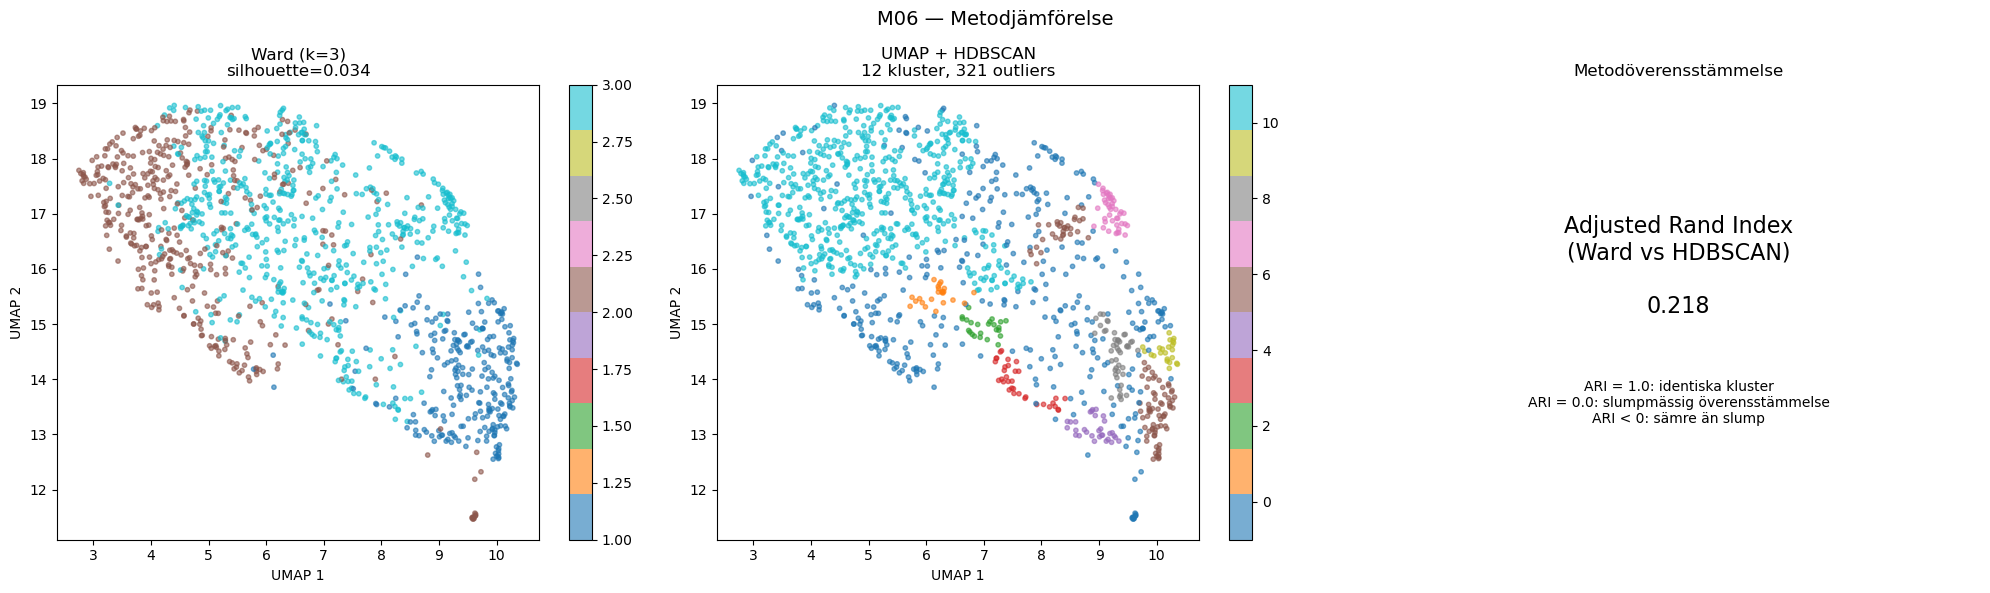

Beräknar Jaccard-distansmatris för M08...
Kör Ward...
Ward silhouette: 0.048
Kör UMAP...


/opt/anaconda3/envs/exjobb/lib/python3.11/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/opt/anaconda3/envs/exjobb/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Kör HDBSCAN...
HDBSCAN hittade 10 kluster, 214 outliers
HDBSCAN silhouette (exkl. outliers): -0.008
Adjusted Rand Index (Ward vs HDBSCAN): 0.623


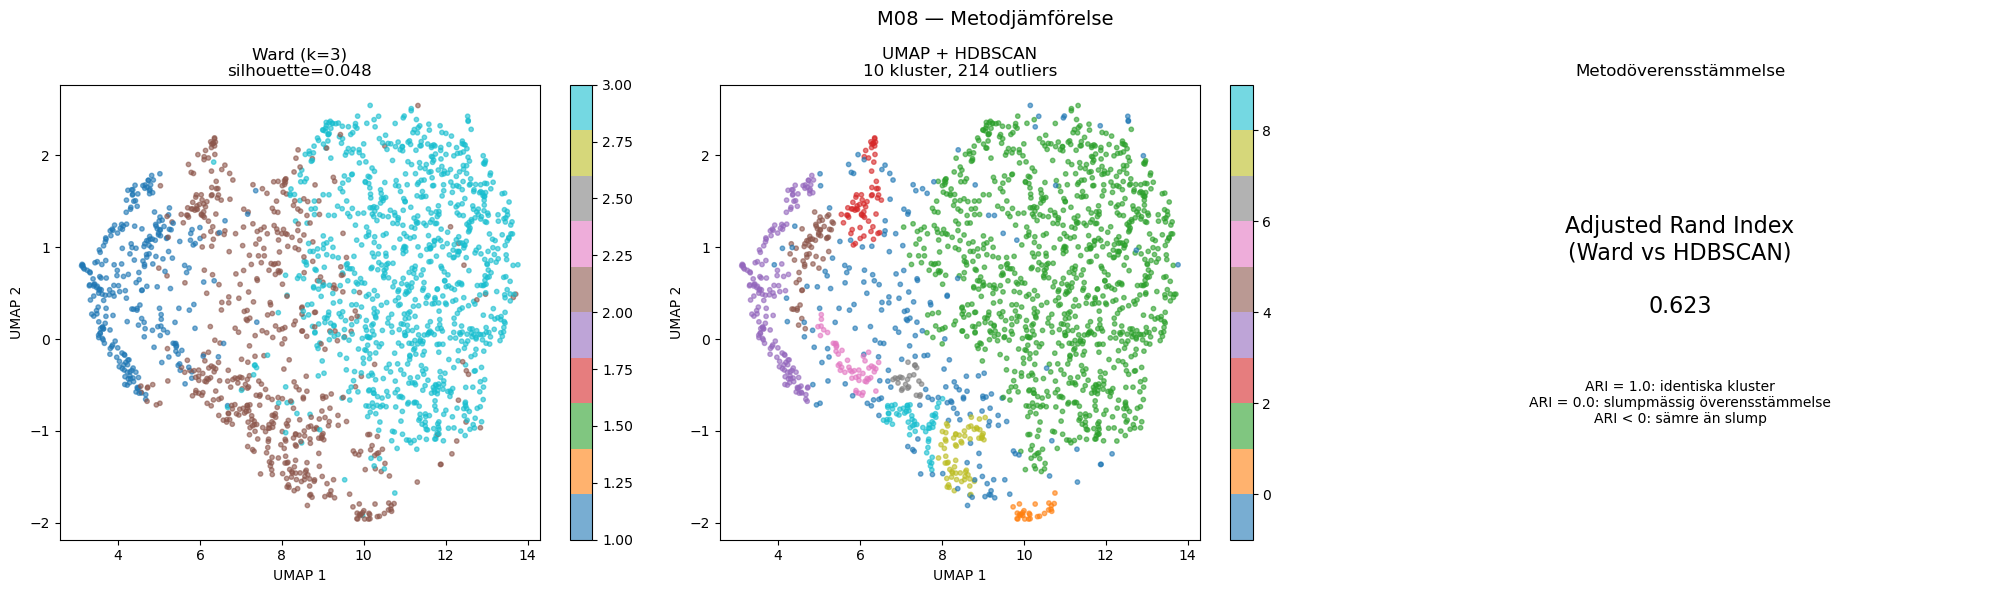

In [68]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
import umap
import hdbscan
from sklearn.metrics import adjusted_rand_score, silhouette_score

def run_all_methods(mat, name, protein_names, k_ward=4):
    """
    Kör Ward, UMAP+HDBSCAN och jämför resultaten.
    """
    
    # --- Gemensam Jaccard-distansmatris ---
    print(f"Beräknar Jaccard-distansmatris för {name}...")
    condensed = pdist(mat, metric='jaccard')
    dist_mat = squareform(condensed)
    
    # ── METOD 1: Ward hierarkisk klustring ────────────────────────────────────
    print("Kör Ward...")
    Z = linkage(condensed, method='ward')
    labels_ward = fcluster(Z, k_ward, criterion='maxclust')
    
    sil_ward = silhouette_score(dist_mat, labels_ward, metric='precomputed')
    print(f"Ward silhouette: {sil_ward:.3f}")
    
    # ── METOD 2: UMAP + HDBSCAN ───────────────────────────────────────────────
    print("Kör UMAP...")
    reducer = umap.UMAP(
        metric='jaccard',       # använd Jaccard direkt i UMAP
        n_neighbors=15,         # justera: färre = mer lokal struktur
        min_dist=0.1,           # lågt värde = tätare kluster i projektionen
        n_components=2,
        random_state=42
    )
    embedding = reducer.fit_transform(mat)
    
    print("Kör HDBSCAN...")
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=20,    # minsta kluster — justera efter er datamängd
        min_samples=5,          # konservativare = färre outliers
        cluster_selection_method='eom'
    )
    labels_hdbscan = clusterer.fit_predict(embedding)
    
    # HDBSCAN markerar outliers som -1
    n_clusters_hdbscan = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)
    n_outliers = (labels_hdbscan == -1).sum()
    print(f"HDBSCAN hittade {n_clusters_hdbscan} kluster, {n_outliers} outliers")
    
    # Silhouette exkluderar outliers
    mask = labels_hdbscan != -1
    if mask.sum() > 1 and n_clusters_hdbscan > 1:
        sil_hdbscan = silhouette_score(
            dist_mat[np.ix_(mask, mask)], 
            labels_hdbscan[mask], 
            metric='precomputed'
        )
        print(f"HDBSCAN silhouette (exkl. outliers): {sil_hdbscan:.3f}")
    
    # ── Visualisering ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f'{name} — Metodjämförelse', fontsize=14)
    
    # Ward på UMAP-embedding
    scatter1 = axes[0].scatter(
        embedding[:, 0], embedding[:, 1],
        c=labels_ward, cmap='tab10', s=10, alpha=0.6
    )
    axes[0].set_title(f'Ward (k={k_ward})\nsilhouette={sil_ward:.3f}')
    axes[0].set_xlabel('UMAP 1')
    axes[0].set_ylabel('UMAP 2')
    plt.colorbar(scatter1, ax=axes[0])
    
    # HDBSCAN på UMAP-embedding
    colors_hdbscan = labels_hdbscan.copy()
    scatter2 = axes[1].scatter(
        embedding[:, 0], embedding[:, 1],
        c=colors_hdbscan, cmap='tab10', s=10, alpha=0.6
    )
    axes[1].set_title(
        f'UMAP + HDBSCAN\n'
        f'{n_clusters_hdbscan} kluster, {n_outliers} outliers'
    )
    axes[1].set_xlabel('UMAP 1')
    axes[1].set_ylabel('UMAP 2')
    plt.colorbar(scatter2, ax=axes[1])
    
    # Överensstämmelse mellan metoderna (exkl. outliers)
    if mask.sum() > 1 and n_clusters_hdbscan > 1:
        ari = adjusted_rand_score(labels_ward[mask], labels_hdbscan[mask])
        axes[2].text(0.5, 0.6, f'Adjusted Rand Index\n(Ward vs HDBSCAN)\n\n{ari:.3f}',
                    ha='center', va='center', fontsize=16,
                    transform=axes[2].transAxes)
        axes[2].text(0.5, 0.3,
                    'ARI = 1.0: identiska kluster\n'
                    'ARI = 0.0: slumpmässig överensstämmelse\n'
                    'ARI < 0: sämre än slump',
                    ha='center', va='center', fontsize=10,
                    transform=axes[2].transAxes)
        axes[2].set_title('Metodöverensstämmelse')
        axes[2].axis('off')
        print(f"Adjusted Rand Index (Ward vs HDBSCAN): {ari:.3f}")
    
    plt.tight_layout()
    plt.savefig(f'{name}_method_comparison.png', dpi=150)
    plt.show()
    
    return {
        'labels_ward': labels_ward,
        'labels_hdbscan': labels_hdbscan,
        'embedding': embedding,
        'Z': Z
    }


# ── Kör ──────────────────────────────────────────────────────────────────────

results06 = run_all_methods(M06, 'M06', M06, k_ward=k06)
results08 = run_all_methods(M08, 'M08', M08, k_ward=k08)

Inga tydliga kluster; Datan kanske mer handlar om kontinuum - data "flödar" från ett område till ett annat utan naturliga glapp däremellan.

Ward har solhouette = 0.048 vilket innebär att den inte hittar tydlig skillnad på klustrerna. Ward i princip delar upp ett kontinuum godtyckligt.

HDBSCAN tolkar situationen åt andra hållet, många outliers och många kluster. 

ARI på 0.623 säger att metoderna är måttligt överens — de delar ungefär samma grovstruktur men är oense om detaljerna. Den grova indelningen är sannolikt densamma men HDBSCAN splittrar upp Wards kluster i mindre bitar.


# Methodology 2

In [7]:
# Sampla filtered data med stratified och 50-50
df = pd.read_csv("../data/processed/seen.csv")

proteins = [c for c in df.columns if c.startswith("seq.")]
X = df[proteins].copy()
y = df["ards"].astype(int).copy()

print(X.shape, y.shape)
print(y.value_counts())

(326, 10776) (326,)
ards
0    274
1     52
Name: count, dtype: int64


In [7]:
import networkx as nx

from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import train_test_split

def run_ttest_selector(X_sub, y_sub, mode="top_k", top_k=20, alpha=0.05):
    """
    Returnerar binär selektionsvektor och justerade p-värden.
    
    mode:
        - "top_k": välj de top_k minsta FDR-justerade p-värdena
        - "fdr": välj alla med adj_p < alpha
    """
    _, p_vals = stats.ttest_ind(
        X_sub[y_sub == 1],
        X_sub[y_sub == 0],
        axis=0,
        equal_var=False,
        nan_policy="omit"
    )

    p_vals = np.nan_to_num(p_vals, nan=1.0, posinf=1.0, neginf=1.0)
    _, adj_p_vals, _, _ = multipletests(p_vals, alpha=alpha, method="fdr_bh")

    if mode == "top_k":
        k = min(top_k, len(adj_p_vals))
        idx = np.argsort(adj_p_vals)[:k]
        selected = np.zeros(len(adj_p_vals), dtype=int)
        selected[idx] = 1
    elif mode == "fdr":
        selected = (adj_p_vals < alpha).astype(int)
    else:
        raise ValueError("mode must be 'top_k' or 'fdr'")

    return selected, adj_p_vals

In [8]:
def run_subsampling_selection(
    X,
    y,
    n_iter=500,
    subsample_size=0.5,
    selector="ttest",
    mode="top_k",
    top_k=20,
    alpha=0.05,
    random_state=42,
):
    """
    Kör stratifierad subsampling och bygger:
      Z: (n_iter, p) binär selektionsmatris
      P: (n_iter, p) justerade p-värden
    """
    n_samples, n_proteins = X.shape
    Z = np.zeros((n_iter, n_proteins), dtype=int)
    P = np.zeros((n_iter, n_proteins), dtype=float)

    all_idx = np.arange(n_samples)

    for b in range(n_iter):
        sub_idx, _ = train_test_split(
            all_idx,
            train_size=subsample_size,
            stratify=y,
            random_state=random_state + b
        )

        X_sub = X.iloc[sub_idx]
        y_sub = y.iloc[sub_idx]

        if selector == "ttest":
            selected, adj_p_vals = run_ttest_selector(
                X_sub, y_sub,
                mode=mode,
                top_k=top_k,
                alpha=alpha
            )
        else:
            raise NotImplementedError("Börja med selector='ttest'")

        Z[b, :] = selected
        P[b, :] = adj_p_vals

        if (b + 1) % 100 == 0:
            print(f"Iteration {b+1}/{n_iter}")

    return Z, P

In [9]:
Z, P = run_subsampling_selection(
    X, y,
    n_iter=300,
    subsample_size=0.5,
    selector="ttest",
    mode="top_k",   # rekommenderas
    top_k=20,
    alpha=0.05,
    random_state=42
)

print("Z shape:", Z.shape)
print("P shape:", P.shape)

Iteration 100/300
Iteration 200/300
Iteration 300/300
Z shape: (300, 10776)
P shape: (300, 10776)


In [12]:
Z.mean(axis = 0)

array([0.00333333, 0.        , 0.        , ..., 0.00666667, 0.        ,
       0.        ])

In [7]:
pi = Z.mean(axis=0)
pi_series = pd.Series(pi, index=proteins).sort_values(ascending=False)

pi_series.head(20)

seq.18205.123    0.546667
seq.23224.11     0.516667
seq.26103.20     0.430000
seq.17813.21     0.396667
seq.33451.35     0.320000
seq.22528.1      0.290000
seq.34860.5      0.226667
seq.9834.62      0.223333
seq.31183.95     0.200000
seq.21269.198    0.200000
seq.25094.9      0.200000
seq.24646.47     0.196667
seq.3538.26      0.193333
seq.12351.25     0.190000
seq.19120.33     0.163333
seq.17768.50     0.156667
seq.12372.50     0.153333
seq.25267.10     0.153333
seq.30349.19     0.143333
seq.23256.21     0.143333
dtype: float64

In [8]:
# Filtrera proteiner
pi_thr = 0.05
keep_mask = pi >= pi_thr

Z_filt = Z[:, keep_mask]
proteins_filt = np.array(proteins)[keep_mask]
pi_filt = pi[keep_mask]

print("Proteins kept:", len(proteins_filt))

Proteins kept: 91


In [9]:
R = np.corrcoef(Z_filt, rowvar=False)
R = np.nan_to_num(R, nan=0.0)

R.shape

(91, 91)

Kanterna innebär att de väljs oftare än förväntat tillsammans

In [10]:
# bygg graf
def build_coselection_graph(R, protein_names, edge_thr=0.15):
    G = nx.Graph()

    for name in protein_names:
        G.add_node(name)

    p = len(protein_names)
    for i in range(p):
        for j in range(i + 1, p):
            w = R[i, j]
            if w > edge_thr:
                G.add_edge(protein_names[i], protein_names[j], weight=float(w))

    return G

In [11]:
G = build_coselection_graph(R, proteins_filt, edge_thr=0.15)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 91
Edges: 294


In [12]:
# Levain communities
communities = nx.community.louvain_communities(G, weight="weight", seed=42)
len(communities)

8

In [13]:
cluster_map = {}
for k, comm in enumerate(communities):
    for prot in comm:
        cluster_map[prot] = k

cluster_df = pd.DataFrame({
    "protein": proteins_filt,
    "pi": pi_filt,
    "cluster": [cluster_map[p] for p in proteins_filt]
}).sort_values(["cluster", "pi"], ascending=[True, False])

cluster_df["cluster"].value_counts().sort_index()
cluster_df.head(10)

,protein,pi,cluster
90,seq.9834.62,0.223333,0
0,seq.10014.31,0.123333,0
46,seq.23394.125,0.120000,0
42,seq.22817.126,0.110000,0
51,seq.25082.3,0.110000,0
6,seq.12524.18,0.106667,0
9,seq.13580.2,0.106667,0
22,seq.18182.24,0.093333,0
37,seq.21691.27,0.086667,0
29,seq.19237.17,0.066667,0


In [14]:
def plot_graph(G, cluster_map, pi_series_subset=None, figsize=(10,10)):
    plt.figure(figsize=figsize)
    pos = nx.spring_layout(G, seed=42, k=0.25)

    clusters = sorted(set(cluster_map.values()))
    cmap = plt.cm.get_cmap("tab20", len(clusters))

    node_colors = [cmap(cluster_map[n]) for n in G.nodes()]

    if pi_series_subset is not None:
        node_sizes = [100 + 1200 * pi_series_subset.get(n, 0) for n in G.nodes()]
    else:
        node_sizes = 80

    edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
    edge_widths = [1 + 4*w for w in edge_weights]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.25)

    # Labela bara toppnoder för läsbarhet
    if pi_series_subset is not None:
        top_nodes = pi_series_subset.sort_values(ascending=False).head(20).index
        labels = {n: n for n in G.nodes() if n in top_nodes}
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

    plt.title("Co-selection graph")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

/var/folders/rz/3cfhhdrd2bs65msqx2gtqcph0000gn/T/ipykernel_93448/1969914490.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(clusters))


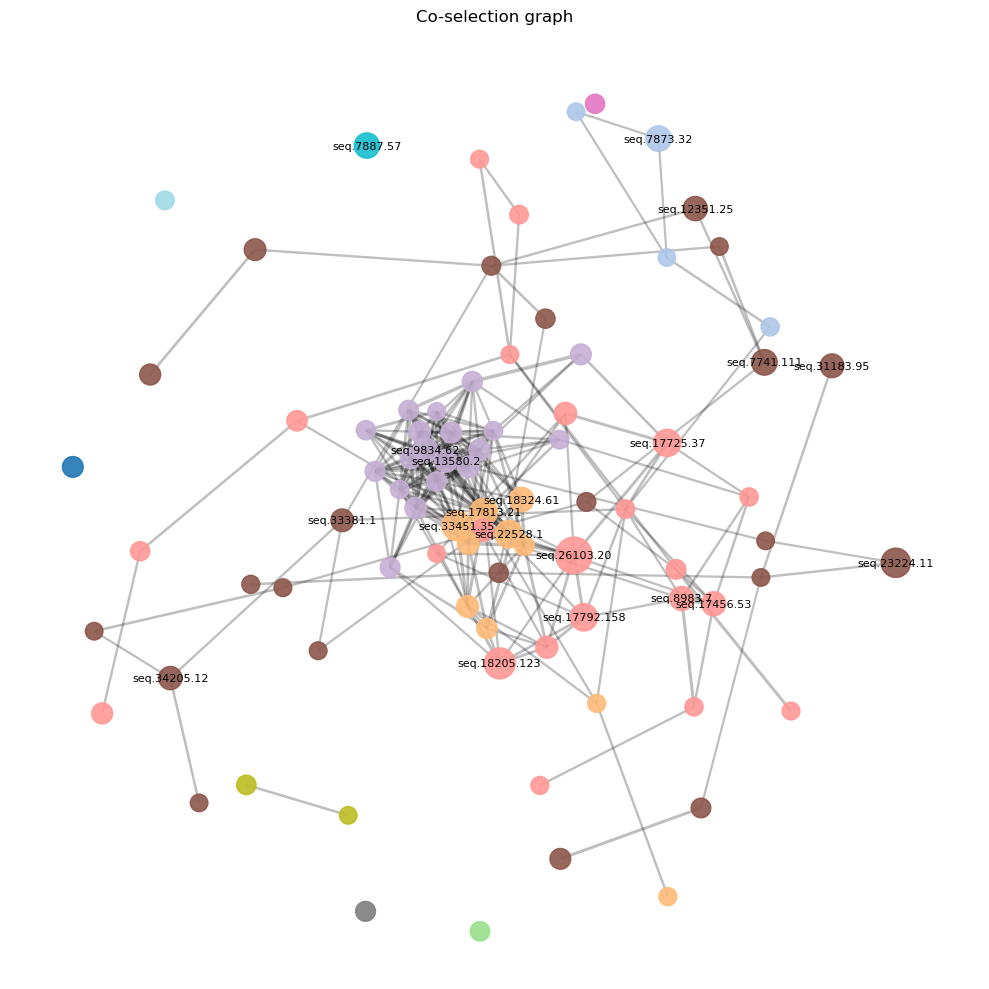

In [91]:
pi_series_filt = pd.Series(pi_filt, index=proteins_filt)
plot_graph(G, cluster_map, pi_series_subset=pi_series_filt)

/var/folders/rz/3cfhhdrd2bs65msqx2gtqcph0000gn/T/ipykernel_80963/1969914490.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(clusters))


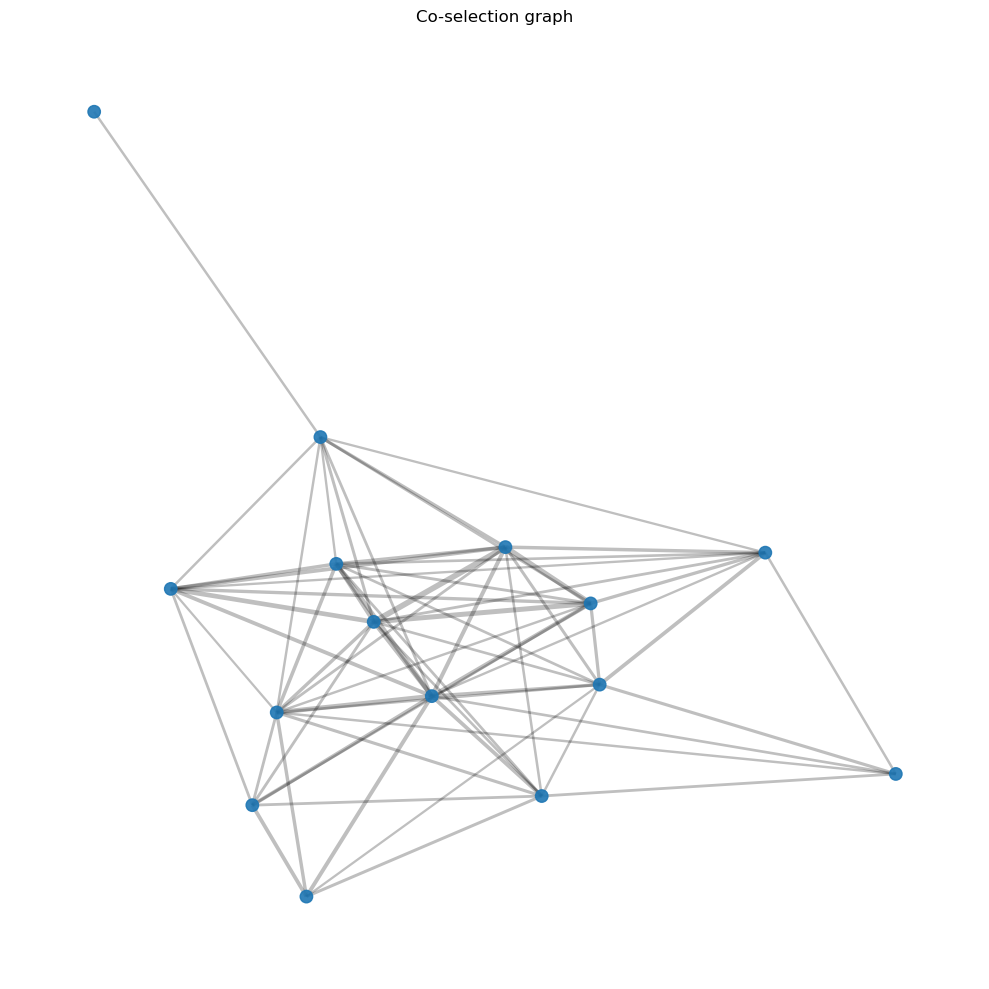

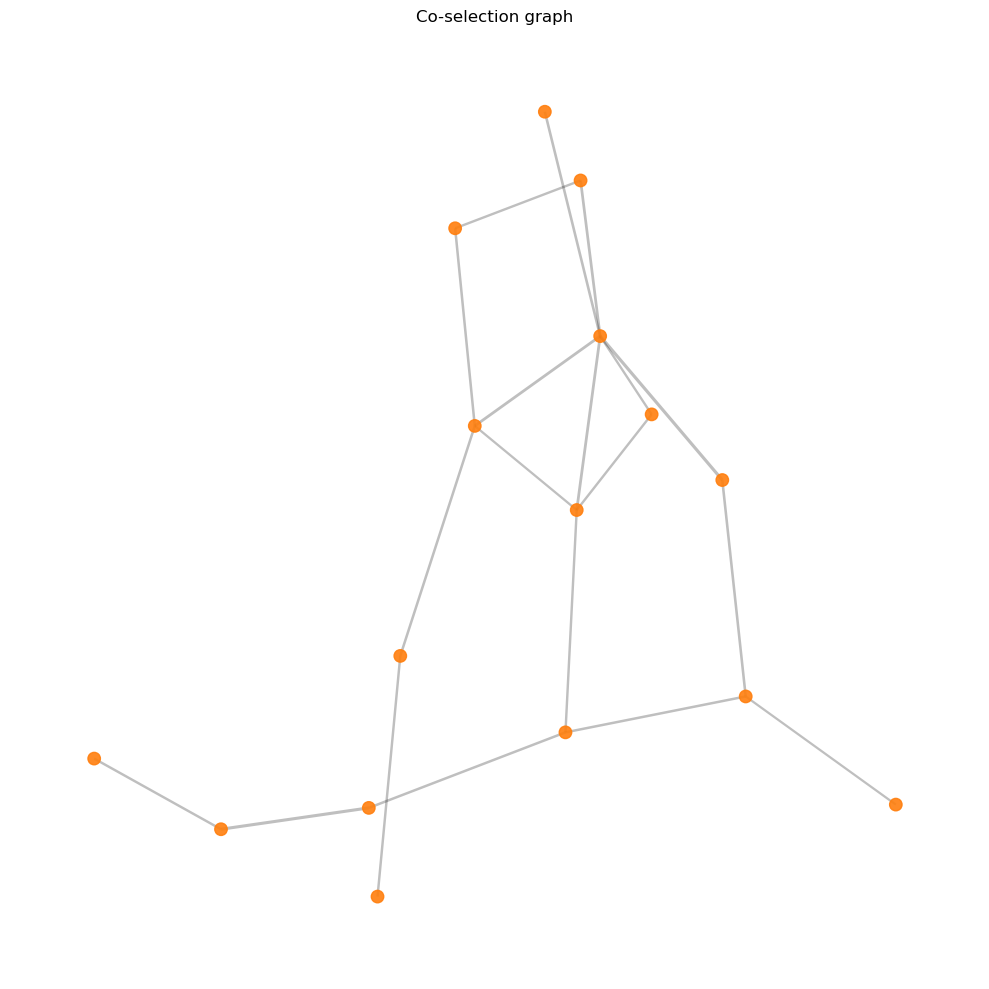

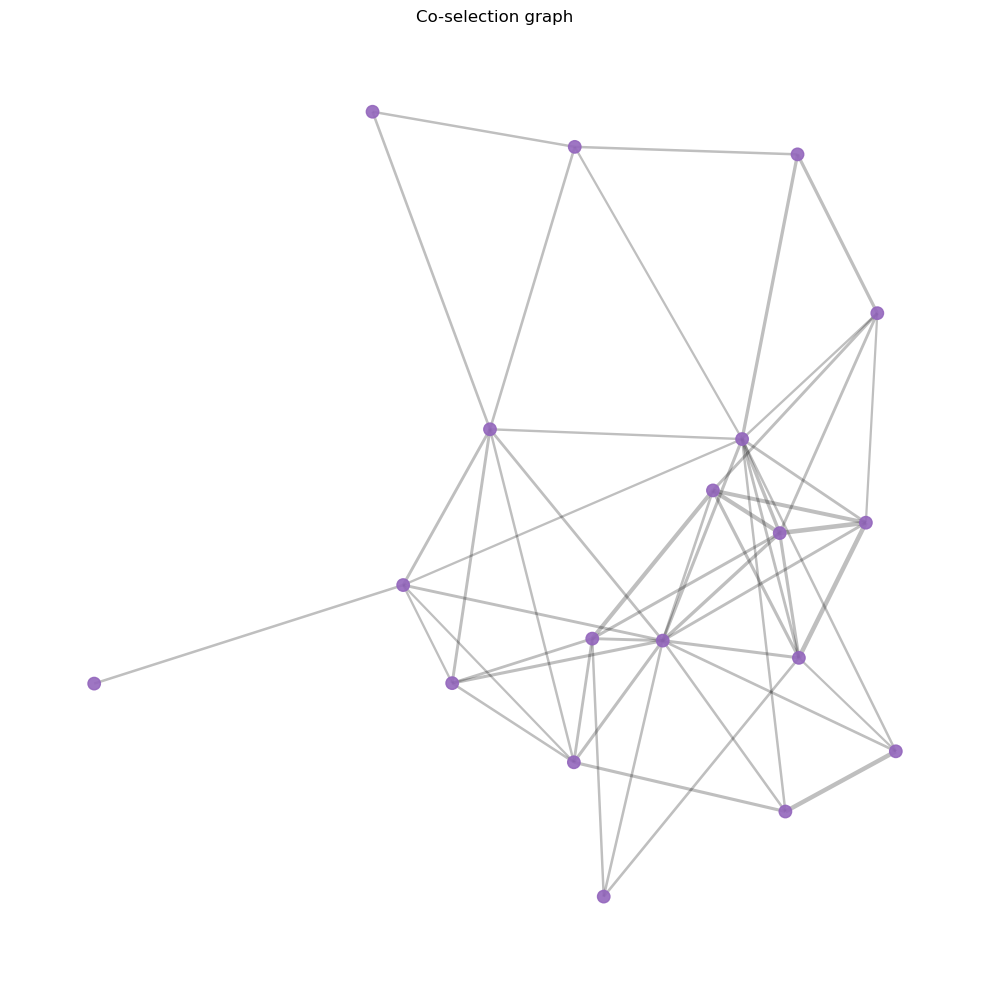

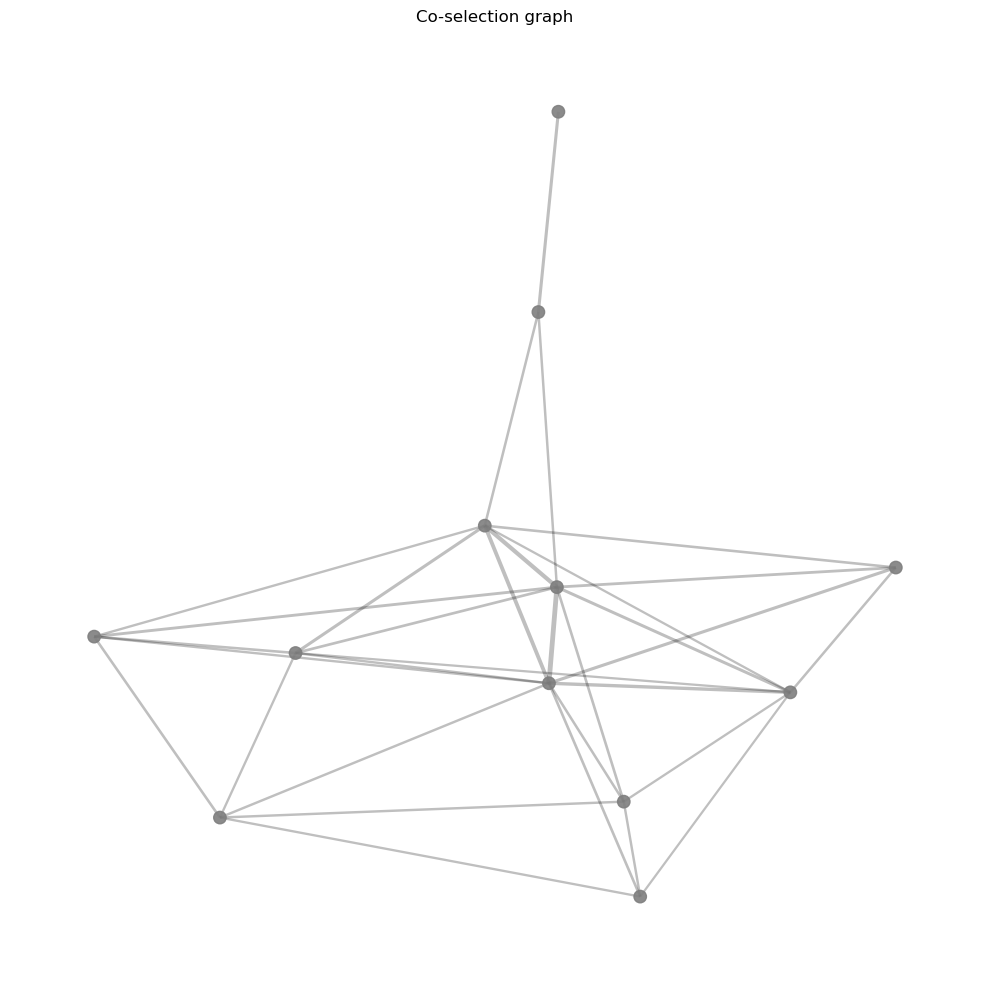

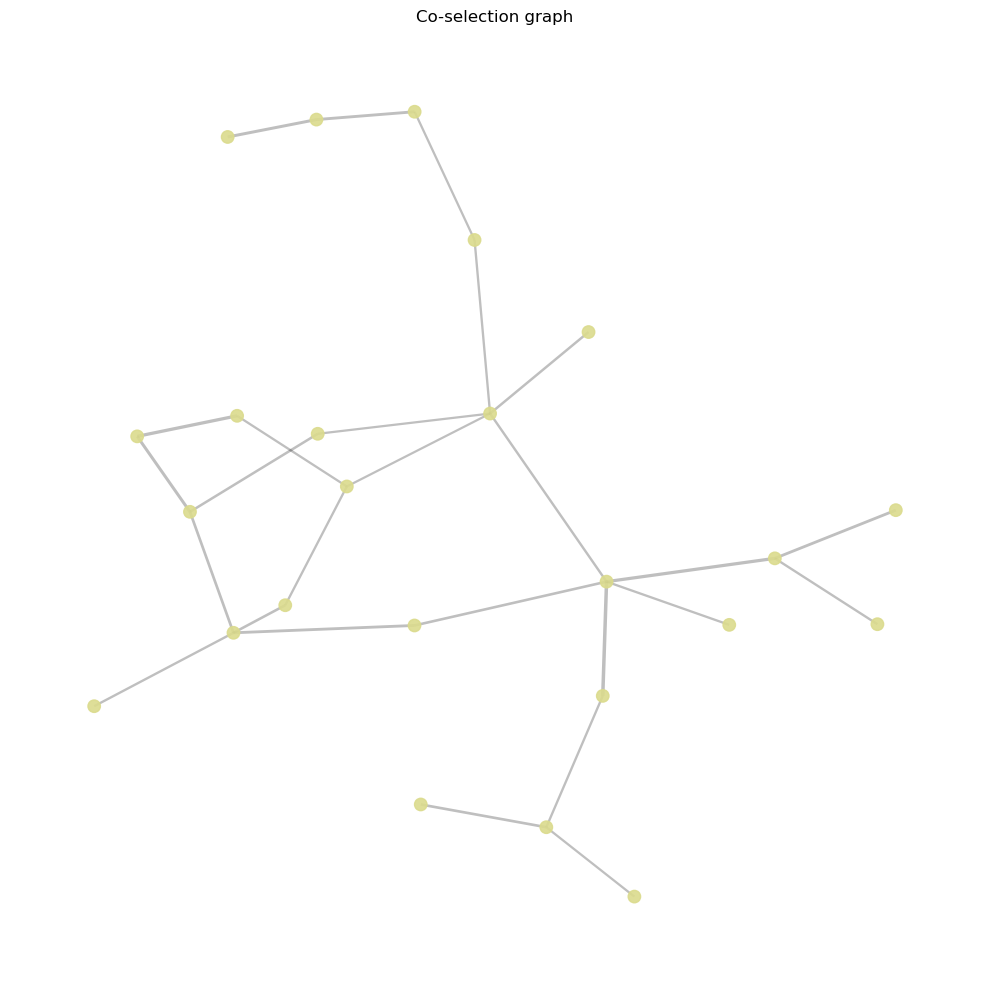

In [15]:
for k in set(cluster_map.values()):
    nodes = [n for n in G.nodes() if cluster_map[n] == k]
    subG = G.subgraph(nodes)
    if len(subG.nodes()) > 5:
        plot_graph(subG, cluster_map)

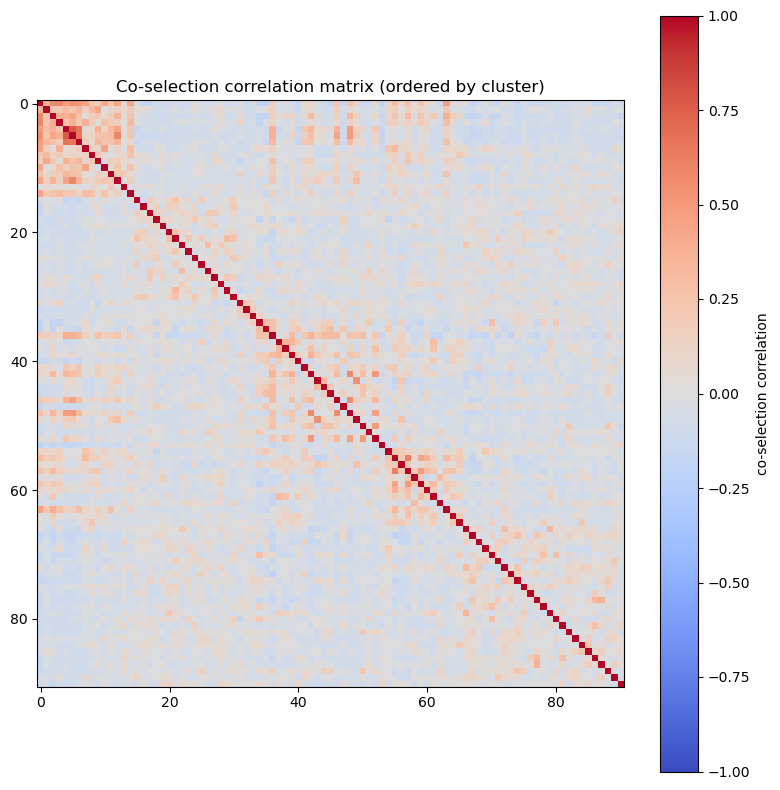

In [16]:
order = cluster_df.sort_values(["cluster", "pi"], ascending=[True, False])["protein"].values
order_idx = [np.where(proteins_filt == p)[0][0] for p in order]

R_ord = R[np.ix_(order_idx, order_idx)]

plt.figure(figsize=(8,8))
plt.imshow(R_ord, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="co-selection correlation")
plt.title("Co-selection correlation matrix (ordered by cluster)")
plt.tight_layout()
plt.show()

In [17]:
# print proteins in sorted order on descending pi values
cluster_df.sort_values("pi", ascending=False)[["protein", "pi", "cluster"]].reset_index(drop=True)

,protein,pi,cluster
0,seq.18205.123,0.546667,3
1,seq.23224.11,0.516667,1
2,seq.26103.20,0.430000,3
3,seq.17813.21,0.396667,3
4,seq.33451.35,0.320000,5
...,...,...,...
86,seq.19568.17,0.050000,1
87,seq.3728.52,0.050000,1
88,seq.8326.63,0.050000,1
89,seq.28156.64,0.050000,0


In [19]:
# A set of proteins with the highest selection frequency (pi) in each cluster
top_proteins_per_cluster = cluster_df.groupby("cluster").apply(lambda df: df.sort_values("pi", ascending=False).head(1))
print(top_proteins_per_cluster[["protein", "pi"]])

                  protein        pi
cluster                            
0       90    seq.9834.62  0.223333
1       44   seq.23224.11  0.516667
2       40    seq.22528.1  0.290000
3       24  seq.18205.123  0.546667
4       66   seq.31183.95  0.200000
5       71   seq.33451.35  0.320000
6       73    seq.34860.5  0.226667
7       89    seq.9173.21  0.120000


/var/folders/rz/3cfhhdrd2bs65msqx2gtqcph0000gn/T/ipykernel_80963/1942828876.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_proteins_per_cluster = cluster_df.groupby("cluster").apply(lambda df: df.sort_values("pi", ascending=False).head(1))


## Klassificering 
Strategi A: Top-N proteiner från co-selection moduler\
Strategi B: Top-N proteiner från selektionsfrekvens π_i (mest stabila)\
Strategi C: Klassisk feature selection (t-test, lasso, etc.) som baseline\

In [30]:
unseen = pd.read_csv("../data/processed/unseen.csv")

Modul 0 representanter: ['seq.9834.62', 'seq.10014.31']
Modul 1 representanter: ['seq.23224.11', 'seq.15466.30']
Modul 2 representanter: ['seq.22528.1', 'seq.20075.130']
Modul 3 representanter: ['seq.18205.123', 'seq.26103.20']
Modul 4 representanter: ['seq.31183.95']
Modul 5 representanter: ['seq.33451.35', 'seq.21269.198']
Modul 6 representanter: ['seq.34860.5', 'seq.12351.25']
Modul 7 representanter: ['seq.9173.21']


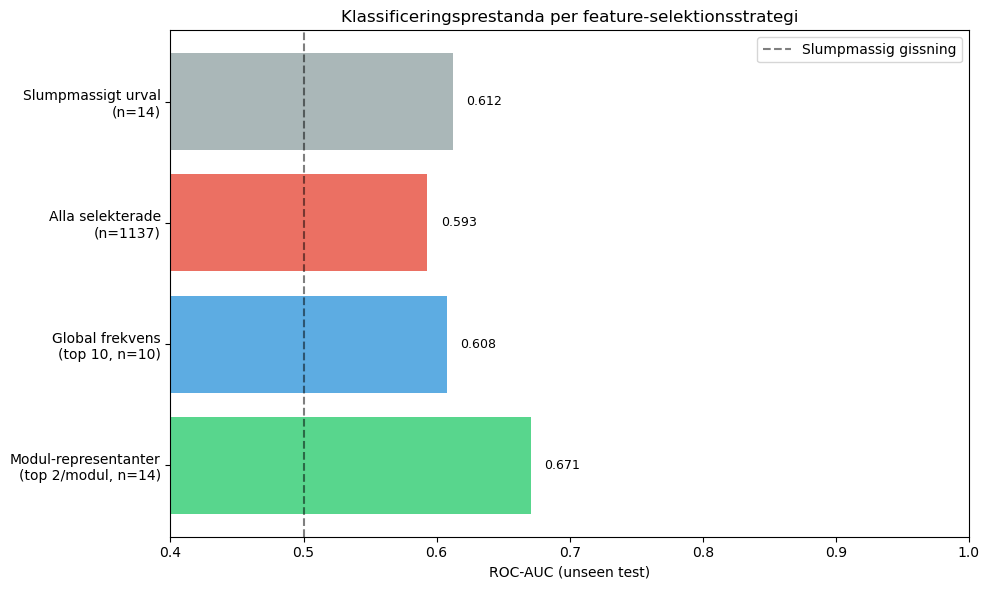


                                     label  n_features  auc_mean  acc_mean
Modul-representanter\n(top 2/modul, n=14)          14  0.670569  0.111111
          Global frekvens\n(top 10, n=10)          10  0.607581  0.000000
               Alla selekterade\n(n=1137)        1137  0.593088  0.000000
               Slumpmassigt urval\n(n=14)          14  0.612040  0.000000


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def evaluate_feature_set(X_train, y_train, X_test, y_test, feature_names, label, classifier='rf'):
    """
    Trana pa seen-data och utvardera pa unseen-data for ett givet feature set.

    feature_names: lista med proteinnamn, pd.Series, eller DataFrame med kolumnen 'protein'
    classifier   : 'lr' = logistisk regression, 'rf' = random forest
    """
    if isinstance(feature_names, pd.DataFrame):
        if "protein" not in feature_names.columns:
            raise ValueError("If feature_names is a DataFrame, it must contain a 'protein' column.")
        selected_features = (
            feature_names["protein"]
            .dropna()
            .astype(str)
            .drop_duplicates()
            .tolist()
        )
    elif isinstance(feature_names, pd.Series):
        selected_features = feature_names.dropna().astype(str).drop_duplicates().tolist()
    else:
        selected_features = pd.Index(feature_names).dropna().astype(str).drop_duplicates().tolist()

    selected_features = [f for f in selected_features if f in X_train.columns and f in X_test.columns]
    if len(selected_features) == 0:
        raise ValueError("No valid features found in both X_train and X_test.")

    Xtr = X_train[selected_features].values
    Xte = X_test[selected_features].values

    if classifier == 'lr':
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=1000, random_state=42))
        ])
    else:
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
        ])

    model.fit(Xtr, y_train)
    y_proba = model.predict_proba(Xte)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)

    return {
        'label': label,
        'n_features': len(selected_features),
        'features': selected_features,
        'auc_mean': auc,
        'auc_std': 0.0,
        'acc_mean': f1,
        'acc_std': 0.0
    }


def compare_strategies(X_train, y_train, X_test, y_test, modules, pi, top_per_module=2, top_n_global=10):
    """
    Jamfor feature-selektionsstrategier pa unseen testdata.

    modules      : dict {module_id: [protein1, protein2, ...]}
                   eller DataFrame med kolumnerna ['cluster', 'protein']
    pi           : pd.Series eller numpy-array med selektionsfrekvens per protein
    """
    if isinstance(modules, pd.DataFrame):
        required_cols = {'cluster', 'protein'}
        if not required_cols.issubset(modules.columns):
            raise ValueError("If modules is a DataFrame, it must contain columns 'cluster' and 'protein'.")
        modules_dict = (
            modules.groupby('cluster')['protein']
            .apply(lambda s: s.dropna().astype(str).tolist())
            .to_dict()
        )
    else:
        modules_dict = modules

    if isinstance(pi, np.ndarray):
        if len(pi) != X_train.shape[1]:
            raise ValueError("If pi is a numpy array, it must have the same length as X_train.columns.")
        pi = pd.Series(pi, index=X_train.columns)
    elif isinstance(pi, pd.Series):
        pi = pi.reindex(X_train.columns)
    else:
        raise ValueError("pi must be a pandas Series or numpy array.")

    results = []

    # Strategi A: Top-N per modul
    module_proteins = []
    for module_id, proteins in modules_dict.items():
        proteins = [p for p in proteins if p in pi.index]
        if len(proteins) == 0:
            continue
        module_pi = pi.loc[proteins].dropna().nlargest(top_per_module)
        module_proteins.extend(module_pi.index.tolist())
        print(f"Modul {module_id} representanter: {module_pi.index.tolist()}")

    module_proteins = list(set(module_proteins))
    results.append(evaluate_feature_set(
        X_train, y_train, X_test, y_test, module_proteins,
        label=f'Modul-representanter\n(top {top_per_module}/modul, n={len(module_proteins)})'
    ))

    # Strategi B: Global selektionsfrekvens
    global_top = pi.dropna().nlargest(top_n_global).index.tolist()
    results.append(evaluate_feature_set(
        X_train, y_train, X_test, y_test, global_top,
        label=f'Global frekvens\n(top {top_n_global}, n={len(global_top)})'
    ))

    # Strategi C: Alla selekterade
    all_selected = pi[pi > 0].dropna().index.tolist()
    results.append(evaluate_feature_set(
        X_train, y_train, X_test, y_test, all_selected,
        label=f'Alla selekterade\n(n={len(all_selected)})'
    ))

    # Strategi D: Slumpmassigt urval
    all_proteins = X_train.columns.tolist()
    random_n = max(1, len(module_proteins))
    random_proteins = np.random.choice(all_proteins, size=random_n, replace=False).tolist()
    results.append(evaluate_feature_set(
        X_train, y_train, X_test, y_test, random_proteins,
        label=f'Slumpmassigt urval\n(n={len(random_proteins)})'
    ))

    # Visualisering
    fig, ax = plt.subplots(figsize=(10, 6))
    labels = [r['label'] for r in results]
    aucs = [r['auc_mean'] for r in results]

    colors = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']
    bars = ax.barh(labels, aucs, color=colors, alpha=0.8)

    ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Slumpmassig gissning')
    ax.set_xlabel('ROC-AUC (unseen test)')
    ax.set_title('Klassificeringsprestanda per feature-selektionsstrategi')
    ax.set_xlim(0.4, 1.0)
    ax.legend()

    for bar, auc in zip(bars, aucs):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{auc:.3f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('strategy_comparison_unseen.png', dpi=150)
    plt.show()

    df_results = pd.DataFrame(results)[
        ['label', 'n_features', 'auc_mean', 'auc_std', 'acc_mean', 'acc_std', 'features']
    ]
    print("\n", df_results[['label', 'n_features', 'auc_mean', 'acc_mean']].to_string(index=False))

    return df_results


X_unseen = unseen[proteins].copy()
y_unseen = unseen['ards'].astype(int).copy()

results = compare_strategies(
    X_train=X,
    y_train=y,
    X_test=X_unseen,
    y_test=y_unseen,
    modules=cluster_df,
    pi=pi,
    top_per_module=2,
    top_n_global=10,
    )

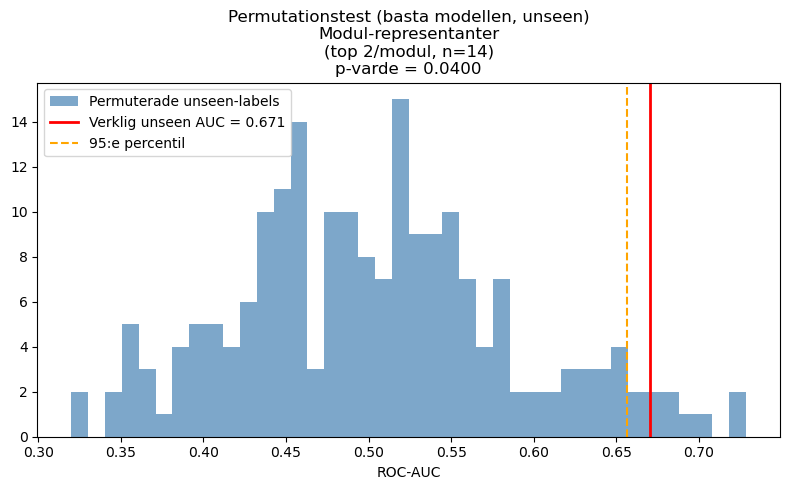

Basta strategi: Modul-representanter
(top 2/modul, n=14)
Antal features: 14
Verklig unseen AUC: 0.671
Permuterad unseen AUC (medel): 0.503
P-varde: 0.0400
Presterar samre med permuterade labels: True


In [32]:
def permutation_validation_best_model(
    X_train, y_train, X_test, y_test, results_df, cluster_df=None, pi=None,
    n_permutations=200, classifier="rf", random_state=42,
    top_per_module=2, top_n_global=10,
    ):
    """Permutationstest for basta modellen, utvarderad endast pa unseen-data."""
    if not {"label", "auc_mean"}.issubset(results_df.columns):
        raise ValueError("results_df must contain 'label' and 'auc_mean'.")

    best_row = results_df.loc[results_df["auc_mean"].idxmax()]
    best_label = best_row["label"]

    # Prefer exact features if available, else reconstruct from strategy label
    if "features" in results_df.columns and isinstance(best_row.get("features"), (list, tuple, np.ndarray, pd.Series)):
        best_features = list(best_row["features"])
    else:
        if cluster_df is None or pi is None:
            raise ValueError("cluster_df and pi are required when results_df has no 'features' column.")

        if isinstance(pi, np.ndarray):
            pi_series = pd.Series(pi, index=X_train.columns)
        else:
            pi_series = pd.Series(pi).reindex(X_train.columns)

        if "Modul-representanter" in best_label:
            modules = cluster_df.groupby("cluster")["protein"].apply(list).to_dict()
            best_features = []
            for proteins_in_module in modules.values():
                proteins_in_module = [p for p in proteins_in_module if p in pi_series.index]
                best_features.extend(pi_series.loc[proteins_in_module].dropna().nlargest(top_per_module).index.tolist())
            best_features = list(dict.fromkeys(best_features))
        elif "Global frekvens" in best_label:
            best_features = pi_series.dropna().nlargest(top_n_global).index.tolist()
        elif "Alla selekterade" in best_label:
            best_features = pi_series[pi_series > 0].dropna().index.tolist()
        else:
            n_feat = int(best_row.get("n_features", 1))
            rng = np.random.default_rng(random_state)
            best_features = rng.choice(X_train.columns, size=max(1, min(n_feat, X_train.shape[1])), replace=False).tolist()

    best_features = [f for f in best_features if f in X_train.columns and f in X_test.columns]
    if len(best_features) == 0:
        raise ValueError("Best model has no valid features in both train and test.")

    Xtr = X_train[best_features].values
    Xte = X_test[best_features].values

    if classifier == "lr":
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=random_state))
        ])
    else:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(n_estimators=100, random_state=random_state))
        ])

    # Train once on seen data
    model.fit(Xtr, y_train)

    # Real unseen performance
    y_proba = model.predict_proba(Xte)[:, 1]
    real_auc = roc_auc_score(y_test, y_proba)

    # Permuted unseen performance (same predictions, permuted unseen labels)
    y_test_arr = np.asarray(y_test)
    perm_aucs = np.array([
        roc_auc_score(np.random.permutation(y_test_arr), y_proba)
        for _ in range(n_permutations)
    ])
    p_value = (perm_aucs >= real_auc).mean()

    plt.figure(figsize=(8, 5))
    plt.hist(perm_aucs, bins=40, alpha=0.7, color="steelblue", label="Permuterade unseen-labels")
    plt.axvline(real_auc, color="red", linewidth=2, label=f"Verklig unseen AUC = {real_auc:.3f}")
    plt.axvline(np.percentile(perm_aucs, 95), color="orange", linestyle="--", label="95:e percentil")
    plt.title(f"Permutationstest (basta modellen, unseen)\n{best_label}\np-varde = {p_value:.4f}")
    plt.xlabel("ROC-AUC")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Basta strategi:", best_label)
    print("Antal features:", len(best_features))
    print(f"Verklig unseen AUC: {real_auc:.3f}")
    print(f"Permuterad unseen AUC (medel): {perm_aucs.mean():.3f}")
    print(f"P-varde: {p_value:.4f}")
    print("Presterar samre med permuterade labels:", perm_aucs.mean() < real_auc)

    return real_auc, perm_aucs, p_value, best_label, best_features


real_auc_best, perm_aucs_best, p_value_best, best_label, best_features = permutation_validation_best_model(
    X_train=X,
    y_train=y,
    X_test=X_unseen,
    y_test=y_unseen,
    results_df=results,
    cluster_df=cluster_df,
    pi=pi,
    n_permutations=200,
    classifier="rf",
    random_state=42,
    )

In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# top protein = top 2 from each cluster
top_proteins = cluster_df.groupby("cluster").apply(lambda df: df.sort_values("pi", ascending=False).head(2)).reset_index(drop=True)["protein"].tolist()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sensitivities_ards = []
precisions_ards = []

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

for train_idx, test_idx in skf.split(X, y):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    
    lr.fit(X_train_fold[top_proteins], y_train_fold)
    y_proba_fold = lr.predict(X_test_fold[top_proteins])
    
    # On ARDS cases in this fold:
    ards_mask = y_test_fold == 1
    if ards_mask.sum() > 0:
        sensitivity = (y_proba_fold[ards_mask] > 0.5).mean()
        sensitivities_ards.append(sensitivity)

print(f"Mean sensitivity on ARDS (5-fold CV): {np.mean(sensitivities_ards):.1%}")

/var/folders/rz/3cfhhdrd2bs65msqx2gtqcph0000gn/T/ipykernel_5316/3874553833.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_proteins = cluster_df.groupby("cluster").apply(lambda df: df.sort_values("pi", ascending=False).head(2)).reset_index(drop=True)["protein"].tolist()


Mean sensitivity on ARDS (5-fold CV): 19.5%


# From scripts

## t-tests

In [13]:
from pathlib import Path
import sys
import networkx as nx
sys.path.append(str(Path("..").resolve()))

from scripts.method2_sub_selection import run_method2_sub_selection

cluster_df, G, pi_ci_df = run_method2_sub_selection(
    input_data="../data/processed/seen.csv",
    selector="ttest",
)

display(cluster_df.head())
print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

,protein,pi,cluster,ci_lower,ci_upper,ci_width,stable_10pct,stable_20pct
0,seq.9834.62,0.223333,0,0.176667,0.270000,0.093333,True,False
1,seq.10014.31,0.123333,0,0.086667,0.156667,0.070000,False,False
2,seq.23394.125,0.120000,0,0.083333,0.160000,0.076667,False,False
3,seq.22817.126,0.110000,0,0.076583,0.143333,0.066750,False,False
4,seq.25082.3,0.110000,0,0.073333,0.143333,0.070000,False,False


Nodes: 91 Edges: 294


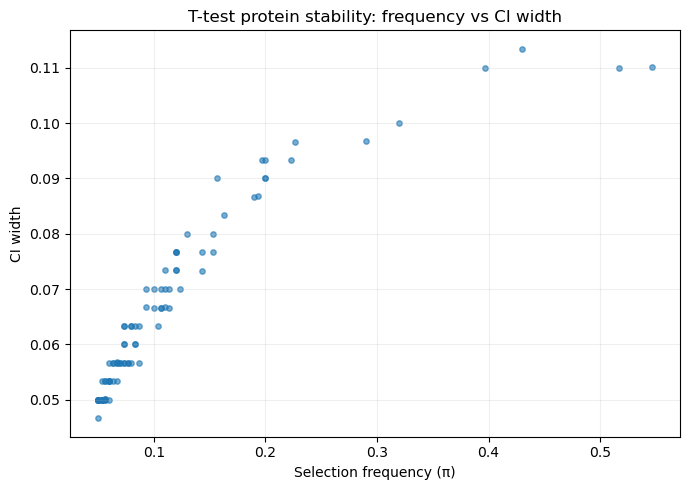

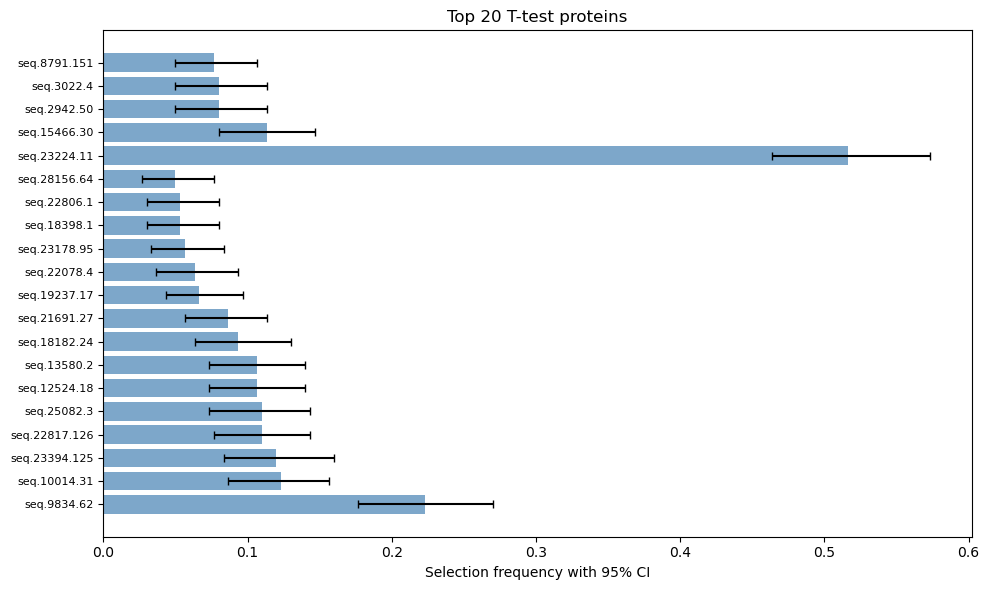

In [14]:
# Plot: frequency vs CI width
plt.figure(figsize=(7, 5))
plt.scatter(cluster_df["pi"], cluster_df["ci_width"], s=15, alpha=0.6)
plt.xlabel("Selection frequency (π)")
plt.ylabel("CI width")
plt.title("T-test protein stability: frequency vs CI width")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Plot: top proteins with error bars
top_n = 20
top_prots = cluster_df.head(top_n)
fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(top_prots))
errors = [
    top_prots["pi"].values - top_prots["ci_lower"].values,
    top_prots["ci_upper"].values - top_prots["pi"].values
]

ax.barh(y_pos, top_prots["pi"].values, xerr=errors, capsize=3, alpha=0.7, color='steelblue')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_prots["protein"].values, fontsize=8)
ax.set_xlabel("Selection frequency with 95% CI")
ax.set_title(f"Top {top_n} T-test proteins")
plt.tight_layout()
plt.show()

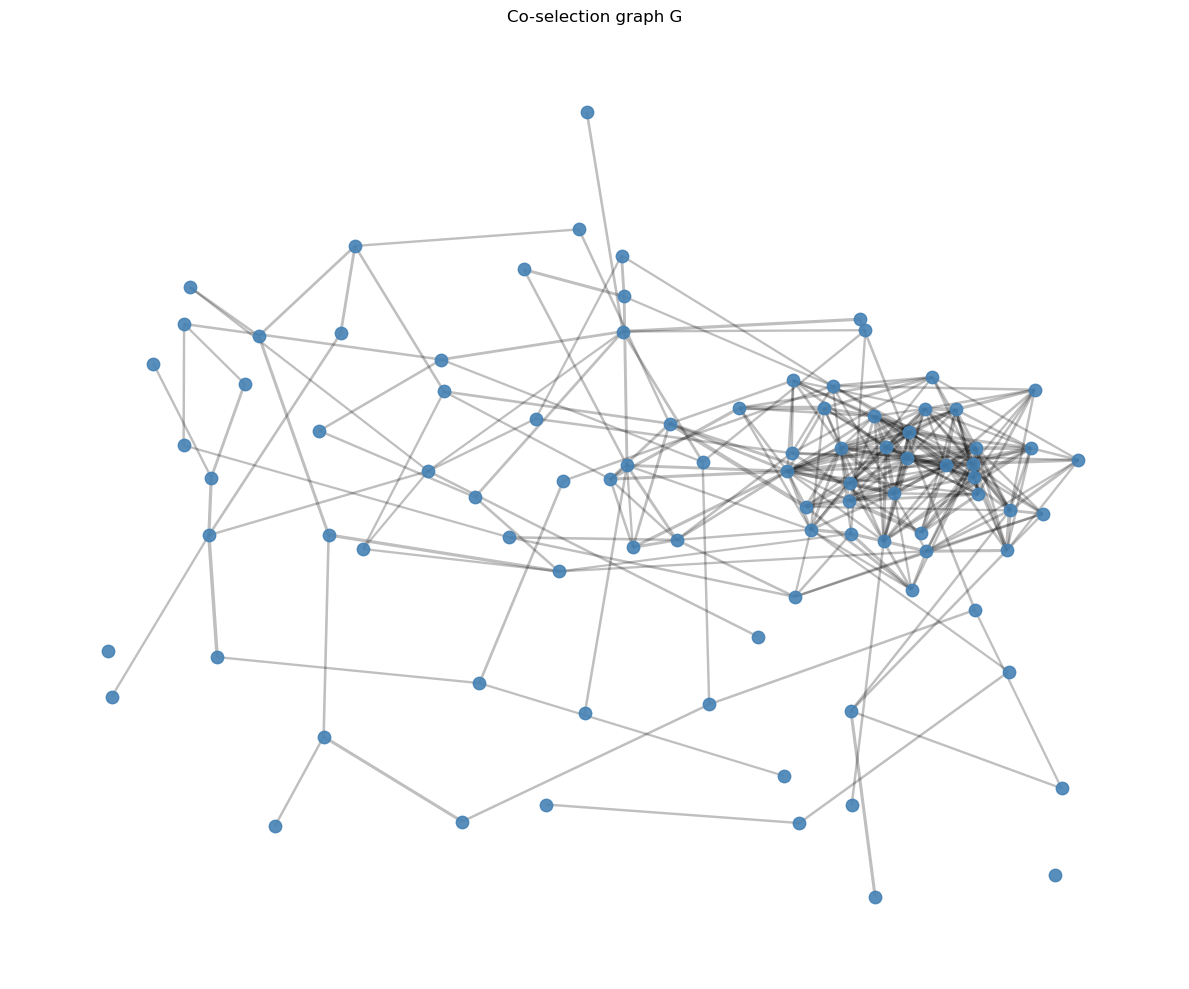

In [3]:
# Plot G

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42, k=0.25)

if "cluster_map" in globals():
    clusters = sorted(set(cluster_map.values()))
    cmap = plt.cm.get_cmap("tab20", max(1, len(clusters)))
    node_colors = [cmap(cluster_map.get(n, 0)) for n in G.nodes()]
else:
    node_colors = "steelblue"

if "pi_series_filt" in globals():
    node_sizes = [100 + 1200 * float(pi_series_filt.get(n, 0)) for n in G.nodes()]
else:
    node_sizes = 80

if G.number_of_edges() > 0:
    edge_widths = [1 + 4 * float(d.get("weight", 0.0)) for _, _, d in G.edges(data=True)]
else:
    edge_widths = 1

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.25)

# Label only top nodes by pi for readability
if "pi_series_filt" in globals():
    top_nodes = pi_series_filt.sort_values(ascending=False).head(20).index
    labels = {n: n for n in G.nodes() if n in top_nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

plt.title("Co-selection graph G")
plt.axis("off")
plt.tight_layout()
plt.show()

In [16]:
# Run sub_selection_validation from notebook using cluster_df as input
from pathlib import Path
from scripts.sub_selection_validation import run_sub_selection_validation

results_df_script, perm_result_script = run_sub_selection_validation(
    cluster_input=cluster_df,
    seen_input="../data/processed/seen.csv",
    unseen_input="../data/processed/unseen.csv",
    classifier="lr",
    top_per_cluster=2,
    top_k_pi=10,
    n_permutations=200,
    random_state=42,
)

display(results_df_script)
print("Best strategy:", perm_result_script["best_label"])
print("Best unseen AUC:", round(perm_result_script["real_auc_unseen"], 3))
print("Permutation p-value:", round(perm_result_script["p_value"], 4))

,label,n_features,features,auc_pr,auc_roc,sensitivity,specificity,precision,balanced_accuracy,f1,confusion_matrix,y_test,y_pred
0,Random,14,"[seq.9372.157, seq.12784.10, seq.6075.61, seq....",0.460648,0.716834,0.769231,0.492754,0.222222,0.630992,0.344828,"[[34, 35], [3, 10]]","[0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, ...","[1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, ..."
1,Top2PerCluster,14,"[seq.9834.62, seq.10014.31, seq.23224.11, seq....",0.293354,0.641026,0.461538,0.695652,0.222222,0.578595,0.300000,"[[48, 21], [7, 6]]","[0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, ...","[1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, ..."
2,Top10Pi,10,"[seq.18205.123, seq.23224.11, seq.26103.20, se...",0.181438,0.567447,0.461538,0.623188,0.187500,0.542363,0.266667,"[[43, 26], [7, 6]]","[0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, ...","[1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, ..."


Best strategy: Random


KeyError: 'real_auc_unseen'

## RF shap

In [61]:
rf_cluster_df = pd.read_csv("../results/rf_sub_selection/cluster_df.csv")

In [67]:
# sort on pi
rf_cluster_df = rf_cluster_df.sort_values("pi", ascending=False).reset_index(drop=True)
display(rf_cluster_df.head())


,protein,pi,cluster
0,seq.26102.249,0.3500,0
1,seq.23224.11,0.1500,2
2,seq.35332.3,0.1250,0
3,seq.19590.46,0.1000,4
4,seq.5007.1,0.0875,4


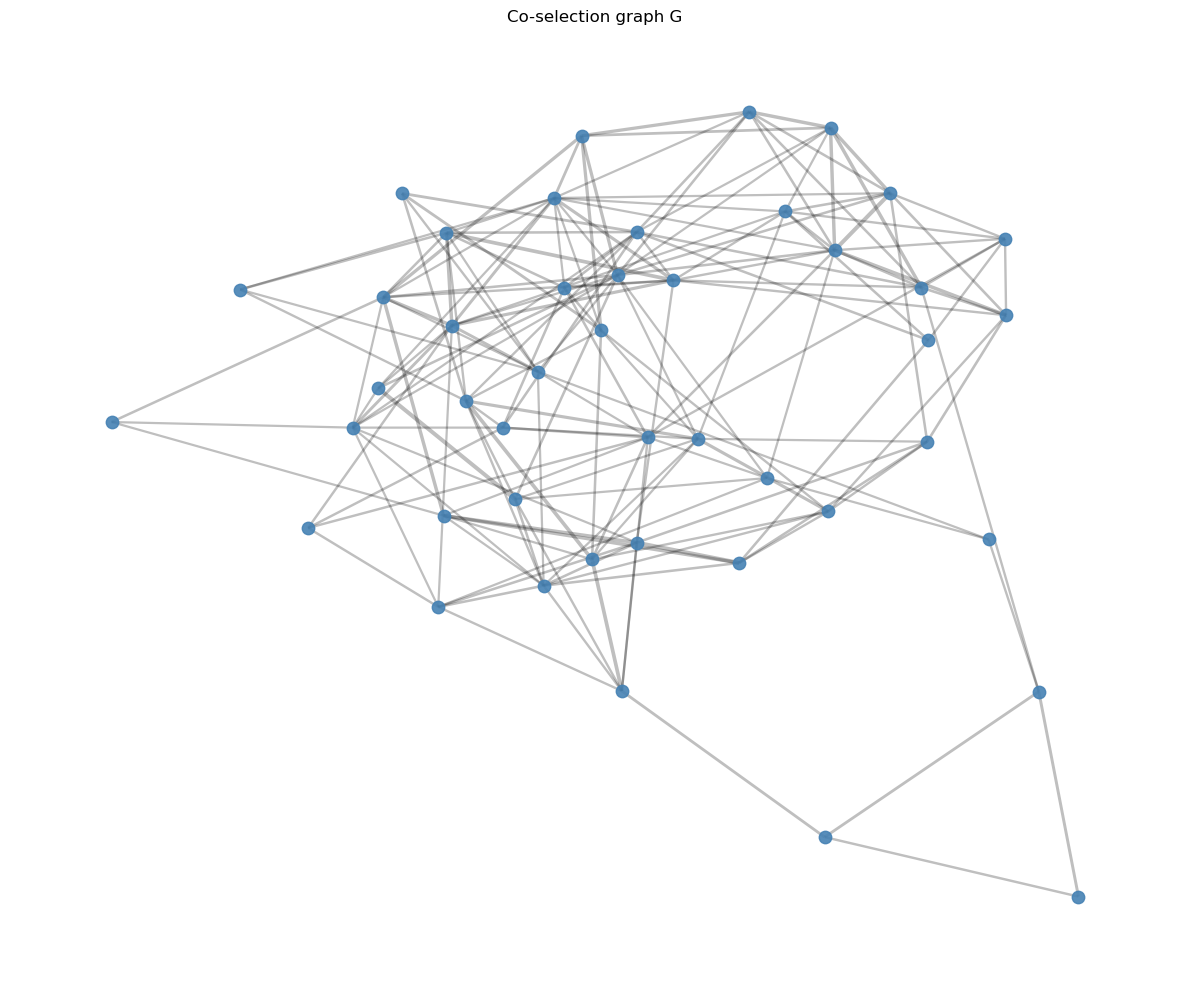

In [71]:
# Plot G

G_rf = nx.read_graphml("../results/rf_sub_selection/graph.graphml")

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G_rf, seed=42, k=0.25)

if "cluster_map" in globals():
    clusters = sorted(set(cluster_map.values()))
    cmap = plt.cm.get_cmap("tab20", max(1, len(clusters)))
    node_colors = [cmap(cluster_map.get(n, 0)) for n in G_rf.nodes()]
else:
    node_colors = "steelblue"

if "pi_series_filt" in globals():
    node_sizes = [100 + 1200 * float(pi_series_filt.get(n, 0)) for n in G_rf.nodes()]
else:
    node_sizes = 80

if G_rf.number_of_edges() > 0:
    edge_widths = [1 + 4 * float(d.get("weight", 0.0)) for _, _, d in G_rf.edges(data=True)]
else:
    edge_widths = 1

nx.draw_networkx_nodes(G_rf, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G_rf, pos, width=edge_widths, alpha=0.25)

# Label only top nodes by pi for readability
if "pi_series_filt" in globals():
    top_nodes = pi_series_filt.sort_values(ascending=False).head(20).index
    labels = {n: n for n in G_rf.nodes() if n in top_nodes}
    nx.draw_networkx_labels(G_rf, pos, labels=labels, font_size=8)

plt.title("Co-selection graph G")
plt.axis("off")
plt.tight_layout()
plt.show()

In [75]:
from scripts.sub_selection_validation import run_sub_selection_validation

results_df_script, perm_result_script = run_sub_selection_validation(
    cluster_input=rf_cluster_df,
    seen_input="../data/processed/seen.csv",
    unseen_input="../data/processed/unseen.csv",
    classifier="rf",
    top_per_cluster=2,
    top_k_pi=10,
    n_permutations=200,
    random_state=42,
)

display(results_df_script)

,label,n_features,features,auc_pr,auc_roc,sensitivity,specificity,precision,balanced_accuracy,f1,confusion_matrix,y_test,y_pred
0,Random,10,"[seq.12729.12, seq.35344.19, seq.12784.10, seq...",0.346842,0.679487,0.153846,1.000000,1.000000,0.576923,0.266667,"[[69, 0], [11, 2]]","[0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,Top10Pi,10,"[seq.26102.249, seq.23224.11, seq.35332.3, seq...",0.245175,0.536789,0.076923,0.985507,0.500000,0.531215,0.133333,"[[68, 1], [12, 1]]","[0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Top2PerCluster,10,"[seq.26102.249, seq.35332.3, seq.28218.30, seq...",0.182835,0.506689,0.076923,0.971014,0.333333,0.523969,0.125000,"[[67, 2], [12, 1]]","[0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."


# Ttester utan multiple correction

In [ ]:
# For the first 100 iterations: print only how many proteins were significant
n_iter_to_show = min(100, sig_matrix.shape[0])

n_significant_per_iteration = sig_matrix[:n_iter_to_show].sum(axis=1).astype(int)

counts_df = pd.DataFrame({
    "iteration": np.arange(1, n_iter_to_show + 1),
    "n_significant_proteins": n_significant_per_iteration,
})

print(counts_df.to_string(index=False))

print("\nSummary (first 100 iterations):")
print(counts_df["n_significant_proteins"].describe())y = df["ards"].astype(int).copy()

In [57]:
from scipy import stats
from itertools import combinations
import matplotlib.colors as mcolors

# sub sample 
N_ITER = 1000
SAMPLE_SIZE = 0.5
ALPHA = 0.05

p_matrix = np.zeros((N_ITER, len(proteins)))  # raw p-values
sig_matrix = np.zeros((N_ITER, len(proteins)), dtype=int)  # 1 = significant

for i in range(N_ITER):
    sub_idx, _ = train_test_split(
        np.arange(X.shape[0]),
        train_size=SAMPLE_SIZE,
        stratify=y,
        random_state=42 + i
    )
    print(f"ARDS in subsample: {y.iloc[sub_idx].sum()}")
    print(f"Healthy in subsample: {(y.iloc[sub_idx] == 0).sum()}")
    X_sub = X.iloc[sub_idx]
    y_sub = y.iloc[sub_idx]

    _, p_vals = stats.mannwhitneyu(
        X_sub[y_sub == 1],
        X_sub[y_sub == 0],
        axis=0,
        alternative='two-sided'
    )
    p_vals = np.nan_to_num(p_vals, nan=1.0)
    p_matrix[i] = p_vals
    sig_matrix[i] = (p_vals < ALPHA).astype(int)

# Frequency summary
# ---------------------------------------------------------------------------
freq = sig_matrix.mean(axis=0)
freq_df = pd.DataFrame({
    "protein": proteins,
    "selection_frequency": freq,
    "n_significant": sig_matrix.sum(axis=0)
}).sort_values("selection_frequency", ascending=False).reset_index(drop=True)

print("Proteins significant in X% of iterations:")
for thr in [1.0, 0.90, 0.75, 0.50, 0.25]:
    print(f"  >= {int(thr*100):3d}%: {(freq >= thr).sum()} proteins")

print(f"\nTop 20:")
print(freq_df.head(20).to_string(index=False))


Proteins significant in X% of iterations:
  >= 100%: 0 proteins
  >=  90%: 4 proteins
  >=  75%: 25 proteins
  >=  50%: 132 proteins
  >=  25%: 624 proteins

Top 20:
      protein  selection_frequency  n_significant
seq.26102.249                0.969            969
 seq.23224.11                0.964            964
  seq.22528.1                0.956            956
seq.25484.120                0.923            923
 seq.31598.17                0.894            894
 seq.12351.25                0.894            894
 seq.34205.12                0.892            892
 seq.10370.21                0.890            890
 seq.30965.75                0.881            881
  seq.35332.3                0.836            836
 seq.18187.16                0.832            832
seq.31307.170                0.807            807
  seq.6557.50                0.797            797
 seq.30349.19                0.797            797
 seq.17391.10                0.789            789
 seq.22059.56                0.786


235 proteins with frequency >= 40%


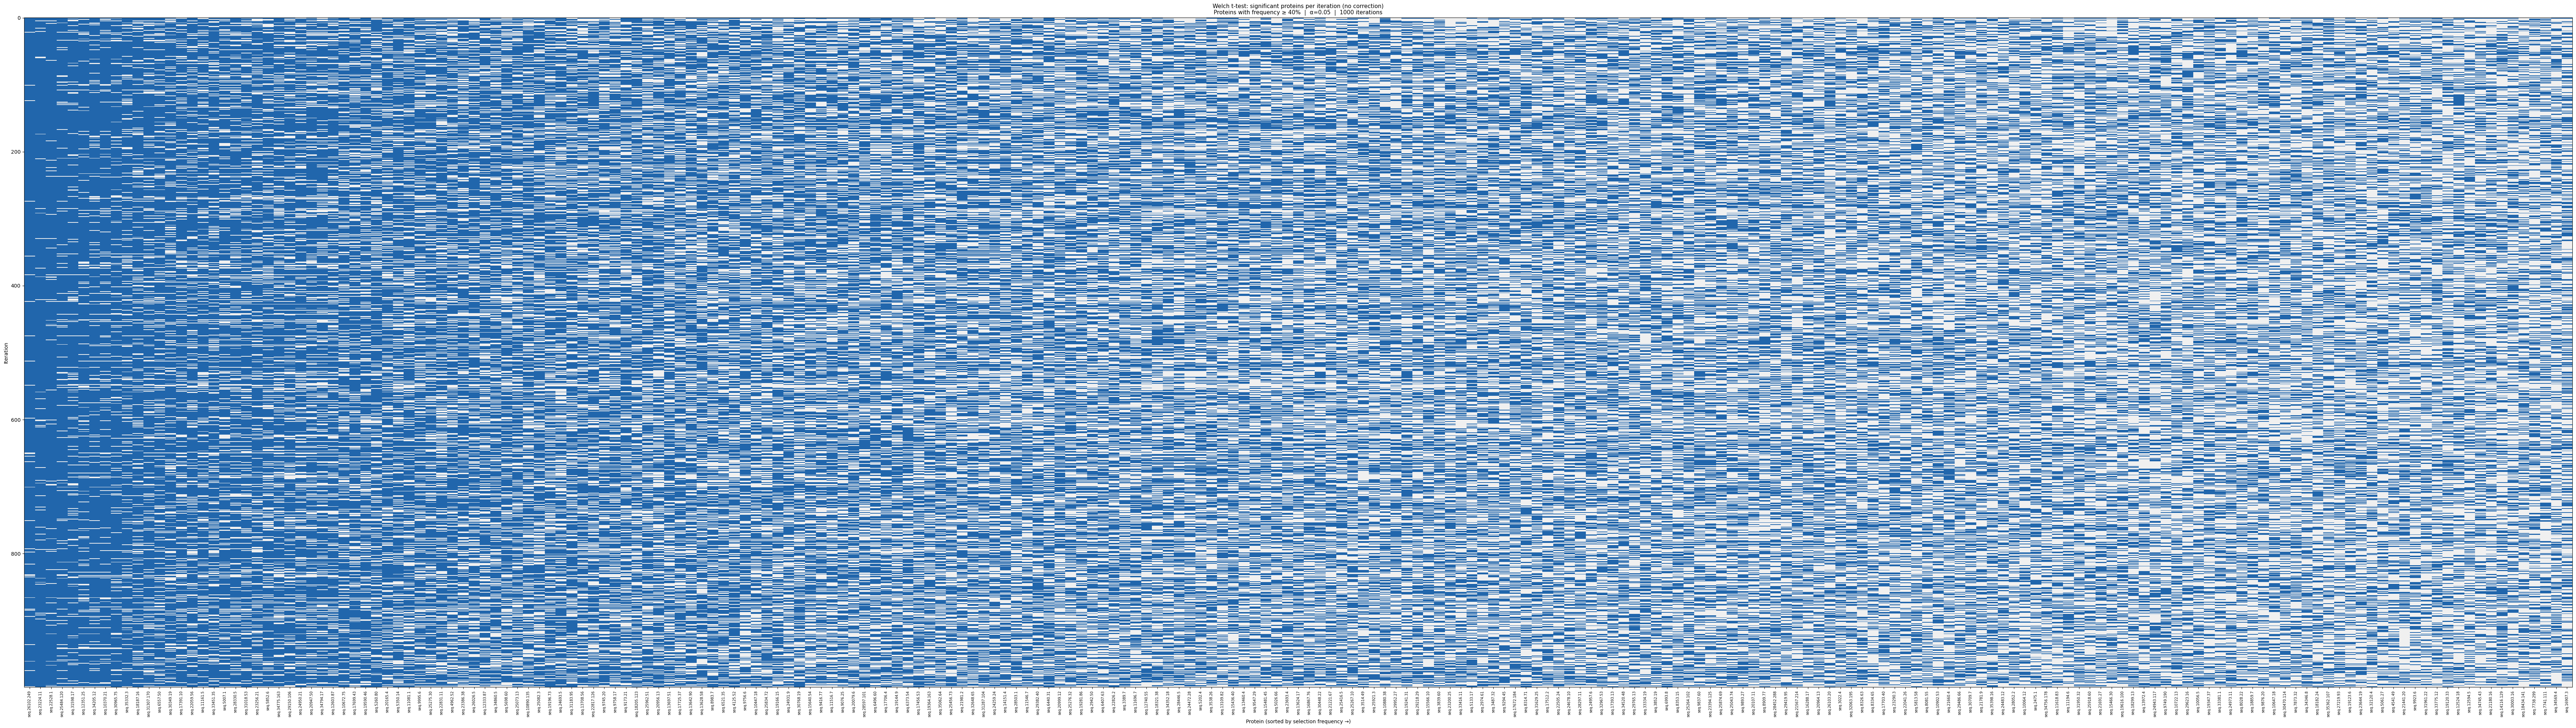

In [78]:
# Heatmap — top proteins by frequency
# ---------------------------------------------------------------------------
FREQ_THR = 0.4

top_mask = freq >= FREQ_THR
top_proteins = np.array(proteins)[top_mask]
top_freq = freq[top_mask]
sort_idx = np.argsort(top_freq)[::-1]
top_proteins_sorted = top_proteins[sort_idx]
Z_top = sig_matrix[:, top_mask][:, sort_idx]

print(f"\n{len(top_proteins)} proteins with frequency >= {int(FREQ_THR*100)}%")

fig, ax = plt.subplots(figsize=(max(10, len(top_proteins_sorted) * 0.3), 20))

cmap = mcolors.ListedColormap(["#f0f0f0", "#2166ac"])
ax.imshow(Z_top, aspect="auto", cmap=cmap, interpolation="none", vmin=0, vmax=1)

ax.set_xticks(range(len(top_proteins_sorted)))
ax.set_xticklabels(top_proteins_sorted, rotation=90, fontsize=7)
ax.set_xlabel("Protein (sorted by selection frequency →)", fontsize=10)
ax.set_ylabel("Iteration", fontsize=10)
ax.set_title(
    f"Welch t-test: significant proteins per iteration (no correction)\n"
    f"Proteins with frequency ≥ {int(FREQ_THR*100)}%  |  α={ALPHA}  |  {N_ITER} iterations",
    fontsize=11
)

plt.tight_layout()
plt.show()



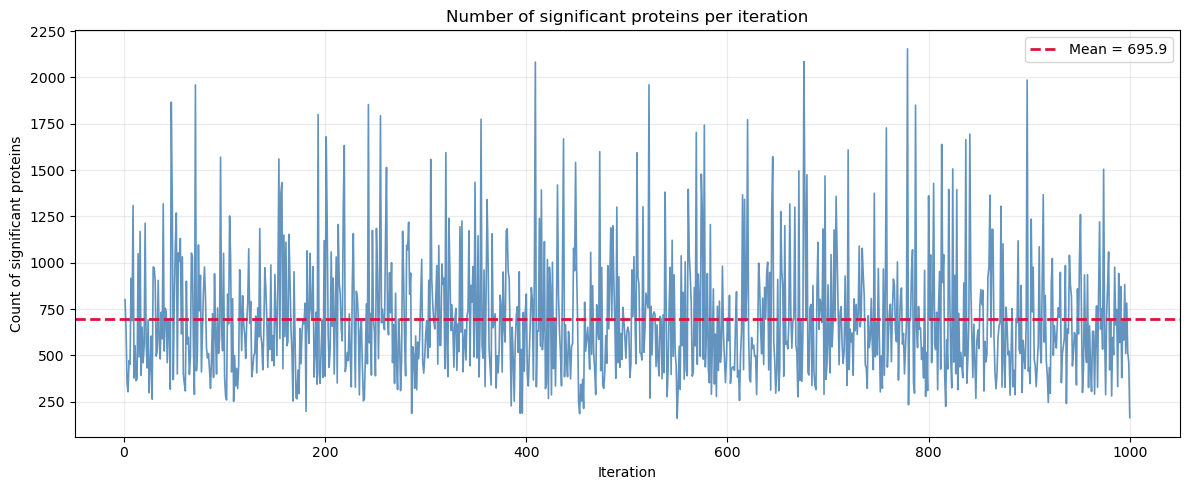

Summary:
count    1000.000000
mean      695.877000
std       335.203448
min       161.000000
25%       450.750000
50%       627.500000
75%       872.000000
max      2154.000000
dtype: float64


In [84]:
# Plot how many significant proteins each iteration gives
n_iter_to_plot = sig_matrix.shape[0]

n_significant_per_iteration = sig_matrix[:n_iter_to_plot].sum(axis=1).astype(int)
iterations = np.arange(1, n_iter_to_plot + 1)

plt.figure(figsize=(12, 5))
plt.plot(iterations, n_significant_per_iteration, linewidth=1.2, alpha=0.85, color="steelblue")
plt.axhline(
    n_significant_per_iteration.mean(),
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {n_significant_per_iteration.mean():.1f}",
)

plt.title("Number of significant proteins per iteration")
plt.xlabel("Iteration")
plt.ylabel("Count of significant proteins")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print("Summary:")
print(pd.Series(n_significant_per_iteration).describe())

Klustra på iterationer, och plotte centroids värden, se att det ena går upp när de andra går ner

In [79]:
# Kmeans clustering of selection patterns

from sklearn.cluster import KMeans
N_CLUSTERS = 5
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42)
clusters = kmeans.fit_predict(sig_matrix)
print(f"\nKMeans clustering of selection patterns (k={N_CLUSTERS}):")
for c in range(N_CLUSTERS):
    cluster_proteins = np.array(proteins)[clusters == c]
    print(f"  Cluster {c+1} ({len(cluster_proteins)} proteins): {', '.join(cluster_proteins[:10])}...")

    


KMeans clustering of selection patterns (k=5):


IndexError: boolean index did not match indexed array along dimension 0; dimension is 10776 but corresponding boolean dimension is 1000